# Vision 2 - Familles comportementales & comparaison entre GAB
## Un GAB est atypique s'il est atypique... de sa propre famille

---

> **Destinataires :** Experts metier - Responsables reseau GAB
> **Objectif :** Regrouper les GAB en familles de comportement homogenes, puis reperer,
> **au sein de chaque famille**, les GAB qui s'en ecartent - plutot qu'un seuil unique
> valable pour tout le reseau, qui penaliserait injustement un GAB urbain tres actif en le
> comparant a un GAB rural.
> **Source des donnees :** dataset Dataiku `fiche_identite_gab_mensuelle` (1 ligne = 1 GAB
> x 1 mois). Aucune donnee synthetique n'est utilisee en production.
> **Perimetre :** France metropolitaine uniquement (DOM-TOM exclus - vision 4).

---

### Ce qui change par rapport a la v10

| v10 | Vision 2 (ce notebook) |
|---|---|
| `k=8` impose pour coller a 8 familles metier pre-nommees | `k` choisi par un diagnostic reel (coude + silhouette) - **pas de nombre de familles decide a l'avance** |
| Nommage par un score heuristique compare a un vocabulaire fixe de 8 archetypes | Nommage **automatique** a partir des traits qui distinguent reellement chaque famille dans les donnees |
| Atypique = le GAB **change de famille** d'un mois a l'autre | Atypique = le GAB est **loin du centre de sa propre famille** (le changement de famille reste suivi, mais en signal secondaire) |
| Le cluster est recalcule mois par mois, sans lissage -> un GAB au comportement stable mais proche d'une frontiere peut "changer de famille" par pur bruit statistique | Le libelle de famille est **lisse** (vote majoritaire sur une fenetre glissante) avant de parler de "changement" |

### Ce que ce notebook produit

1. Choix du nombre de familles **justifie par les donnees**, pas fixe a priori
2. Nommage automatique et lisible metier de chaque famille
3. Score d'atypicite **intra-famille** (distance au centre de sa propre famille)
4. Suivi temporel : eloignement du centre, rapprochement d'une autre famille, changement de famille confirme (lisse)
5. Dashboard de synthese et carte geographique des familles


## 1. Environnement d'execution - Prerequis Dataiku DSS

Memes contraintes que dans `vision1_auto_comparaison_gab` (kernel Python 3.6, pandas 1.1.5,
Plotly 4.11.0) : pas de `dtypes=`/`infer_with_pandas=`, pas de `observed=True`, pas de
`markers=True`/`text_auto`, pas de `include_groups=` sur `groupby().apply()`, et attention aux
colonnes booleennes issues d'un merge (`.fillna(False).astype(bool)` systematique avant tout
`np.select`/comparaison stricte - bug deja rencontre sur la vision 1).

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Librairies
# ══════════════════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
sns.set_style('whitegrid')

RNG_SEED = 42
np.random.seed(RNG_SEED)

# ── Mode d'execution ───────────────────────────────────────────────────────────
# MODE_DEMO = True  -> charge un jeu de donnees FICTIF (comportements normaux +
#                       profils atypiques injectes volontairement, connus a l'avance)
#                       pour valider que le clustering + le score d'atypicite
#                       retrouvent bien ces profils. Aucune donnee reelle LBP.
# MODE_DEMO = False -> charge le vrai dataset Dataiku 'fiche_identite_gab_mensuelle'.
MODE_DEMO = True
CHEMIN_CSV_DEMO = 'dataset_fictif_retrait_complet.csv'
NOM_DATASET_DATAIKU = 'retrait'  # meme source Dataiku que la vision 1 -
                                    # une seule et unique entree pour toutes les visions.
                                    # Grain JOURNALIER (comme la vision 1) - agrege en
                                    # mensuel juste apres le chargement (section 2)

# ── Parametres du clustering ───────────────────────────────────────────────────
PLAGE_K = range(2, 11)          # plage de nombre de familles testee
SEUIL_SILHOUETTE_MINIMUM = 0.18   # separation minimale acceptable - on retient le
                                   # PLUS GRAND k qui reste au-dessus de ce seuil
                                   # (voir section 5 pour la justification complete).
                                   # 0.18 = seuil standard pour une "structure faible
                                   # mais reelle" (reference Kaufman & Rousseeuw) -
                                   # abaisse depuis 0.25 : le silhouette recompense la
                                   # separation geometrique globale et penalisait a tort
                                   # des familles metier-coherentes (verifie par
                                   # comparaison avec une verite terrain simulee :
                                   # k=4 a le meilleur accord avec les vraies familles
                                   # mais un silhouette de 0.19, sous l'ancien seuil).
K_MINIMUM = 5                     # plancher METIER (pas juste statistique) : en-deca
                                   # de 5 familles, le dispositif ne peut de toute facon
                                   # pas distinguer les 5 familles candidates prevues
                                   # dans le nommage hybride (FAMILLES_CANDIDATES,
                                   # section 6) - Rural et Isole sont desormais
                                   # deux familles candidates DISTINCTES (mise a jour
                                   # suite au retour metier : 'rural' et 'isole' ne
                                   # recouvrent pas la meme realite de terrain).
SEUIL_TAILLE_MIN_CLUSTER = 0.05   # une famille de moins de 5% du reseau n'est pas une
                                   # vraie famille metier, c'est un residu statistique -
                                   # un k qui produit un cluster sous ce seuil est rejete
SEUIL_ATYPIQUE_PERCENTILE = 0.90  # un GAB au-dela du 90e percentile de distance
                                   # a SA PROPRE famille est considere atypique
FENETRE_LISSAGE_FAMILLE = 3       # nb d'observations pour le vote majoritaire
                                   # (evite qu'un GAB proche d'une frontiere ne
                                   # "change de famille" a chaque bruit statistique)

print('Configuration chargee.')
print('Mode demo (donnees fictives) :', MODE_DEMO)
print('Plage de k testee :', list(PLAGE_K))
print('Plancher metier K_MINIMUM :', K_MINIMUM)

Configuration chargee.
Mode demo (donnees fictives) : True
Plage de k testee : [2, 3, 4, 5, 6, 7, 8, 9, 10]
Plancher metier K_MINIMUM : 4


## 2. Chargement des donnees et filtre metropole

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Chargement du dataset - Dataiku (production) ou CSV fictif (demo)
# ══════════════════════════════════════════════════════════════════════════════
if MODE_DEMO:
    print('[MODE DEMO] Chargement du jeu de donnees FICTIF : {}'.format(CHEMIN_CSV_DEMO))
    print('[MODE DEMO] Ce jeu de donnees ne represente AUCUNE donnee reelle LBP.')
    df_brut = pd.read_csv(CHEMIN_CSV_DEMO)
else:
    import dataiku
    df_brut = dataiku.Dataset(NOM_DATASET_DATAIKU).get_dataframe()

print('{:,} lignes x {} colonnes (grain journalier - 1 ligne = 1 GAB x jour actif)'.format(
    df_brut.shape[0], df_brut.shape[1]))

# ── Agregation JOURNALIER -> MENSUEL ──────────────────────────────────────────
# Le dataset source ('retrait', meme table que la vision 1) est au grain jour
# (colonne 'jours'), mais la vision 2 raisonne au grain mois : la "famille
# comportementale" d'un GAB est une notion STRUCTURELLE qui n'a de sens que
# lissee sur une periode assez large - la detecter jour par jour ferait changer
# un GAB de famille au moindre bruit quotidien, sans mieux detecter les vraies
# ruptures d'une journee (deja couvert par la vision 1, qui compare chaque GAB
# a son propre historique jour par jour). Les deux visions se completent :
# vision 1 = "ce GAB a-t-il derive AUJOURD'HUI par rapport a lui-meme ?"
# vision 2 = "a quelle famille ce GAB ressemble-t-il CE MOIS-CI, et est-il
#             atypique dans sa propre famille ?"
colonnes_moyennes = [
    'ret_heure_moyenne', 'cap_heure_moyenne', 'ret_pct_nuit', 'ret_pct_weekend',
    'taux_capture_pct', 'taux_capture_cos_pct',
]
colonnes_sommes = [
    'ret_nb', 'ret_nb_jours_actifs', 'ret_montant_total', 'ret_nb_nuit', 'ret_nb_weekend',
    'ret_nb_heure_pointe', 'ret_nb_cos', 'ret_nb_horscos', 'cap_nb', 'cap_nb_nuit',
    'cap_nb_weekend', 'cap_cos_nb', 'cap_nb_oubli_ou_incident_lecture',
    'cap_nb_code_confidentiel_depasse', 'cap_nb_carte_perdue', 'cap_nb_carte_volee',
    'cap_nb_autre_motif', 'cap_nb_motif_inconnu',
]
colonnes_reseau = [c for c in df_brut.columns
                    if c.startswith('nb_ope_reseau_') or c.startswith('montant_reseau_')]
colonnes_sommes += [c for c in colonnes_reseau if c not in colonnes_sommes]
colonnes_premiere = ['code_postale_emplacement', 'longitude', 'latitude']
# Colonnes annexes de TEST uniquement (verite terrain simulee, absentes de la
# vraie table retrait) - conservees si presentes (mode demo) pour continuer a
# valider objectivement le clustering, ignorees silencieusement sinon.
colonnes_test_optionnelles = ['archetype_reel', 'is_gab_anomalie_connue']

if 'jours' in df_brut.columns:
    n_lignes_avant = len(df_brut)

    agg_dict = {}
    for c in colonnes_sommes:
        if c in df_brut.columns:
            agg_dict[c] = (c, 'sum')
    for c in colonnes_moyennes:
        if c in df_brut.columns:
            agg_dict[c] = (c, 'mean')
    for c in colonnes_premiere:
        if c in df_brut.columns:
            agg_dict[c] = (c, 'first')
    for c in colonnes_test_optionnelles:
        if c in df_brut.columns:
            agg_dict[c] = (c, 'first')

    df_brut_mensuel = df_brut.groupby(['num_automate', 'annee', 'mois']).agg(**agg_dict).reset_index()

    # ── Ecart-type MENSUEL des montants - reconstruit par decomposition de la
    # variance (loi de la variance totale) a partir des stats QUOTIDIENNES deja
    # calculees en SQL (ret_montant_moyen, ret_montant_stddev, ret_nb par jour) -
    # plus rigoureux qu'une simple moyenne des ecarts-types quotidiens :
    #   Var_mois = E[Var_jour] (ponderee par ret_nb) + Var[E_jour] (moyennes
    #   quotidiennes ponderees par ret_nb, variance ponderee entre les jours)
    if {'ret_montant_moyen', 'ret_montant_stddev', 'ret_nb'}.issubset(df_brut.columns):
        def _stddev_mensuel(g):
            poids = g['ret_nb'].to_numpy(dtype=float)
            poids_total = poids.sum()
            if poids_total <= 0:
                return np.nan
            moyennes_j = g['ret_montant_moyen'].to_numpy(dtype=float)
            variances_j = np.nan_to_num(g['ret_montant_stddev'].to_numpy(dtype=float)) ** 2
            moyenne_intra = np.average(variances_j, weights=poids)
            moyenne_globale = np.average(moyennes_j, weights=poids)
            variance_inter = np.average((moyennes_j - moyenne_globale) ** 2, weights=poids)
            return np.sqrt(moyenne_intra + variance_inter)

        stddev_mensuel = (
            df_brut.dropna(subset=['ret_montant_moyen'])
            .groupby(['num_automate', 'annee', 'mois'])
            .apply(_stddev_mensuel)
            .rename('ret_montant_stddev_mensuel')
            .reset_index()
        )
        df_brut_mensuel = df_brut_mensuel.merge(
            stddev_mensuel, on=['num_automate', 'annee', 'mois'], how='left')
        df_brut_mensuel['ret_montant_stddev'] = df_brut_mensuel['ret_montant_stddev_mensuel']
        df_brut_mensuel = df_brut_mensuel.drop(columns=['ret_montant_stddev_mensuel'])

    # Montant moyen mensuel : moyenne ponderee des moyennes quotidiennes par ret_nb
    if {'ret_montant_moyen', 'ret_nb'}.issubset(df_brut.columns):
        montant_moyen_mensuel = (
            df_brut.dropna(subset=['ret_montant_moyen'])
            .groupby(['num_automate', 'annee', 'mois'])
            .apply(lambda g: np.average(g['ret_montant_moyen'], weights=g['ret_nb'])
                   if g['ret_nb'].sum() > 0 else np.nan)
            .rename('ret_montant_moyen_mensuel')
            .reset_index()
        )
        df_brut_mensuel = df_brut_mensuel.merge(
            montant_moyen_mensuel, on=['num_automate', 'annee', 'mois'], how='left')
        df_brut_mensuel['ret_montant_moyen'] = df_brut_mensuel['ret_montant_moyen_mensuel']
        df_brut_mensuel = df_brut_mensuel.drop(columns=['ret_montant_moyen_mensuel'])

    df_brut = df_brut_mensuel
    print('Agregation journalier -> mensuel : {:,} lignes-jour -> {:,} lignes GAB x mois.'.format(
        n_lignes_avant, len(df_brut)))
else:
    print('Dataset deja au grain mensuel (pas de colonne "jours") - aucune agregation necessaire.')

# ── Filtre France metropolitaine uniquement ───────────────────────────────────
cp_str = df_brut['code_postale_emplacement'].astype(str)
codes_dom_tom = cp_str.str.startswith(('97', '98'))
n_dom_tom = codes_dom_tom.sum()
if n_dom_tom > 0:
    print('\n{:,} lignes DOM-TOM exclues (codes postaux 97x/98x).'.format(n_dom_tom))
df = df_brut[~codes_dom_tom].copy()
print('Apres filtre metropole : {:,} lignes | {} GAB'.format(
    len(df), df['num_automate'].nunique()))

if len(df) == 0:
    raise ValueError("Aucune ligne apres filtre metropole. Verifiez 'code_postale_emplacement'.")

[MODE DEMO] Chargement du jeu de donnees FICTIF : dataset_fictif_fiche_identite_gab.csv
[MODE DEMO] Ce jeu de donnees ne represente AUCUNE donnee reelle LBP.
10,807 lignes x 69 colonnes (grain journalier - 1 ligne = 1 GAB x jour actif)


Agregation journalier -> mensuel : 10,807 lignes-jour -> 2,160 lignes GAB x mois.
Apres filtre metropole : 2,160 lignes | 60 GAB


## 3. Audit qualite minimal

Meme logique que la vision 1 : on comble les `NULL` numeriques par 0 (absence de ligne SQL
pour ce ratio ce mois-la), on borne les pourcentages a `[0, 100]`, et on supprime les
doublons exacts.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Audit qualite
# ══════════════════════════════════════════════════════════════════════════════
print('-' * 65)
print('  AUDIT DE QUALITE DES DONNEES')
print('-' * 65)

doublons = df.duplicated(subset=['num_automate', 'annee', 'mois']).sum()
if doublons > 0:
    print('[ATTENTION] {} doublons (num_automate, annee, mois) - supprimes.'.format(doublons))
    df = df.drop_duplicates(subset=['num_automate', 'annee', 'mois'], keep='first')

cols_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
manquants = df[cols_numeriques].isnull().sum()
if manquants.sum() > 0:
    print('[ATTENTION] Valeurs manquantes comblees par 0 : {}'.format(
        manquants[manquants > 0].to_dict()))
    df[cols_numeriques] = df[cols_numeriques].fillna(0)

for col in ['ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_pct']:
    if col in df.columns:
        if col != 'taux_capture_pct':
            n_hors_plage = ((df[col] < 0) | (df[col] > 100)).sum()
            borne_haute = 100
        else:
            n_hors_plage = (df[col] < 0).sum()
            borne_haute = df[col].quantile(0.999)
        if n_hors_plage > 0:
            print('[ATTENTION] {} valeurs de {} hors plage plausible - ecretees.'.format(n_hors_plage, col))
        df[col] = df[col].clip(0, borne_haute)

print('\nDataset pret : {:,} lignes x {} colonnes | {} GAB'.format(
    df.shape[0], df.shape[1], df['num_automate'].nunique()))

-----------------------------------------------------------------
  AUDIT DE QUALITE DES DONNEES
-----------------------------------------------------------------

Dataset pret : 2,160 lignes x 66 colonnes | 60 GAB


## 4. Feature engineering - variables comportementales

Repris de la v10 (ces variables avaient deja fait leurs preuves) :
- **`ratio_capture`** : cartes capturees / retraits
- **`cv_montant`** : coefficient de variation du montant (ecart-type / moyenne) - mesure la
  regularite des montants retires
- **`score_horaires_atypiques`** : combinaison % nuit + % week-end
- **`concentration_reseau`** : le GAB est-il domine par un seul reseau de carte ?
- **`pct_reseaux_etrangers`** : part des reseaux JCB/Amex/CUP/Diners dans le total

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature engineering
# ══════════════════════════════════════════════════════════════════════════════
df['ratio_capture'] = df['cap_nb'] / (df['ret_nb_horscos'] + 1)
df['cv_montant'] = df['ret_montant_stddev'] / (df['ret_montant_moyen'] + 0.01)
df['score_horaires_atypiques'] = (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)

COLS_RESEAU = [c for c in df.columns if c.startswith('nb_ope_reseau_')]
COLS_ETRANGERS = [c for c in COLS_RESEAU if any(x in c for x in ['jcb', 'amex', 'diners', 'cup'])]
df['nb_ope_total_reseau'] = df[COLS_RESEAU].sum(axis=1)
df['concentration_reseau'] = df[COLS_RESEAU].max(axis=1) / (df['nb_ope_total_reseau'] + 1)
df['pct_reseaux_etrangers'] = df[COLS_ETRANGERS].sum(axis=1) / (df['nb_ope_total_reseau'] + 1) * 100

# Log-transform du volume de retraits : cette variable peut varier de quelques
# dizaines a plus d'un millier selon le GAB (urbain vs rural). Sans transformation,
# son amplitude ecrase les autres criteres dans le calcul de distance du K-Means,
# meme apres RobustScaler. log1p() ramene les GAB a fort volume et les GAB a
# faible volume sur une echelle comparable aux criteres bornes (%, ratios).
df['log_ret_nb_horscos'] = np.log1p(df['ret_nb_horscos'])

# ── Feature GEOGRAPHIQUE : zone touristique connue, a partir du departement ────
# Le comportement seul (% reseaux etrangers, % nuit, % weekend) ne suffit pas
# toujours a isoler un cluster "Touristique" propre - un profil tres actif la
# nuit peut matcher aussi bien "Nocturne" que "Touristique" (cas reel observe :
# des GAB touristiques avec un usage nocturne marque, coherent avec un usage
# estival/vacances, se retrouvaient rattaches a "Nocturne" par simple egalite de
# score). Ajouter le LIEU renforce le signal comportemental au lieu de le laisser
# seul face a cette ambiguite : departements a forte vocation touristique
# (littoral/montagne) d'apres le referentiel metier (Nice/Cannes 06, Biarritz 64,
# stations de ski 73/74), et departements ruraux peu denses connus (Lozere 48,
# Creuse 23, Cantal 15) pour renforcer symetriquement le signal "Rural / isole".
DEPARTEMENTS_TOURISTIQUES = {'06', '64', '73', '74'}
DEPARTEMENTS_RURAUX_CONNUS = {'48', '23', '15'}

dept_str = df['code_postale_emplacement'].astype(str).str.zfill(5).str[:2]
df['zone_touristique_connue'] = dept_str.isin(DEPARTEMENTS_TOURISTIQUES).astype(int)
df['zone_rurale_connue'] = dept_str.isin(DEPARTEMENTS_RURAUX_CONNUS).astype(int)

print('Variables comportementales ajoutees : ratio_capture, cv_montant, '
      'score_horaires_atypiques, concentration_reseau, pct_reseaux_etrangers')
print('Variables geographiques ajoutees : zone_touristique_connue ({} GAB x mois), '
      'zone_rurale_connue ({} GAB x mois)'.format(
    df['zone_touristique_connue'].sum(), df['zone_rurale_connue'].sum()))
df[['ratio_capture', 'cv_montant', 'score_horaires_atypiques',
    'concentration_reseau', 'pct_reseaux_etrangers']].describe().round(2)

Variables comportementales ajoutees : ratio_capture, cv_montant, score_horaires_atypiques, concentration_reseau, pct_reseaux_etrangers
Variables geographiques ajoutees : zone_touristique_connue (576 GAB x mois), zone_rurale_connue (684 GAB x mois)


,ratio_capture,cv_montant,score_horaires_atypiques,concentration_reseau,pct_reseaux_etrangers
count,2160.00,2160.00,2160.00,2160.00,2160.00
mean,0.03,0.38,2.70,0.79,7.15
std,0.03,0.04,1.67,0.11,7.06
min,0.00,0.22,0.05,0.48,0.00
25%,0.00,0.36,1.48,0.73,1.68
50%,0.01,0.38,2.10,0.81,4.26
75%,0.05,0.41,3.66,0.88,11.36
max,0.16,0.60,6.50,0.98,28.65


## 5. Choix du nombre de familles - methode du coude + silhouette

**Contrairement a la v10, aucun nombre de familles n'est fixe a l'avance.** On teste
plusieurs valeurs de k et on retient celle qui separe le mieux les groupes (score de
silhouette le plus eleve). Si les donnees ne contiennent naturellement que 3 ou 4 profils
distincts, forcer 8 familles reviendrait a couper artificiellement des groupes homogenes en
sous-groupes qui ne veulent rien dire metier - ce qui rendait justement les familles de la
v10 peu "parlantes".

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Selection des features de clustering + exclusion des valeurs extremes + normalisation
# ══════════════════════════════════════════════════════════════════════════════
FEAT_CLUST = [
    'ret_pct_nuit', 'ret_pct_weekend', 'pct_reseaux_etrangers',
    'log_ret_nb_horscos', 'ret_montant_moyen', 'taux_capture_pct',
    'cv_montant', 'score_horaires_atypiques', 'concentration_reseau',
    'zone_touristique_connue', 'zone_rurale_connue',
]
FEAT_CLUST = [f for f in FEAT_CLUST if f in df.columns]
print('Features de clustering ({}) : {}'.format(len(FEAT_CLUST), FEAT_CLUST))

# Exclusion des valeurs EXTREMES avant de choisir k et fitter le clustering des
# FAMILLES : un incident ponctuel massif (taux de capture 10x la normale) cree un
# point tres eloigne de tout qui, a lui seul, peut faire basculer le diagnostic
# silhouette vers un decoupage "normal vs incident" au lieu de reveler les vraies
# familles de comportement. Ces GAB extremes ne sont pas perdus : ils seront
# quand meme rattaches a la famille dont ils sont le plus proches (section 7),
# et rattraper par les visions 1 et 3 de toute facon.
q1, q3 = df['taux_capture_pct'].quantile([.25, .75])
iqr = q3 - q1
SEUIL_EXCLUSION_EXTREME = q3 + 3 * iqr
masque_population_normale = df['taux_capture_pct'] <= SEUIL_EXCLUSION_EXTREME
n_extremes = (~masque_population_normale).sum()
if n_extremes > 0:
    print('{} observations extremes exclues du CHOIX DE k (pas de l\'analyse) - '
          'taux_capture_pct > {:.1f}.'.format(n_extremes, SEUIL_EXCLUSION_EXTREME))

X = df[FEAT_CLUST].fillna(0)
scaler_clust = RobustScaler()
scaler_clust.fit(X[masque_population_normale])   # scaler ajuste sur la population normale uniquement
X_scaled = scaler_clust.transform(X)

Features de clustering (11) : ['ret_pct_nuit', 'ret_pct_weekend', 'pct_reseaux_etrangers', 'log_ret_nb_horscos', 'ret_montant_moyen', 'taux_capture_pct', 'cv_montant', 'score_horaires_atypiques', 'concentration_reseau', 'zone_touristique_connue', 'zone_rurale_connue']


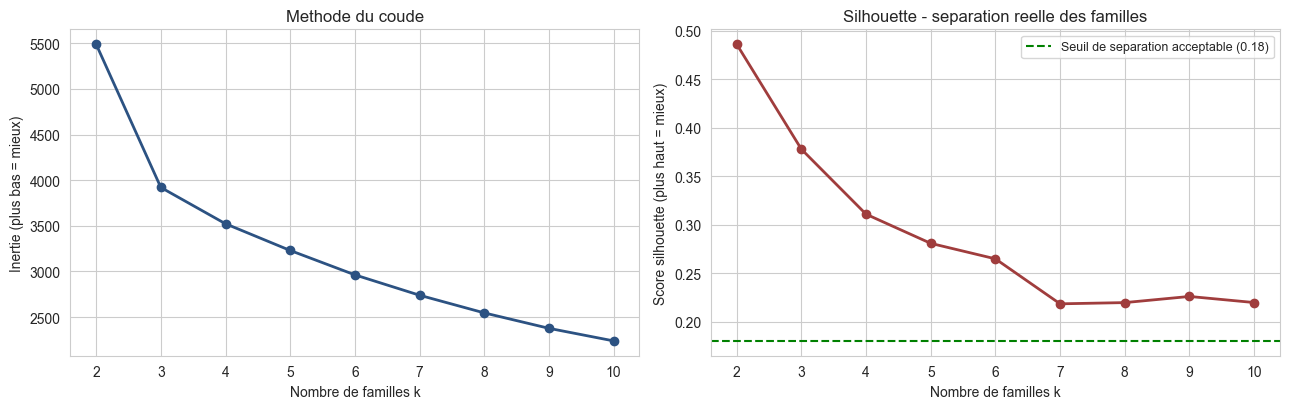


k retenu : 4 (silhouette = 0.311, plus petit cluster = 19.5%, gain marginal vs k-1 = 10.2%)
Seuils : silhouette >= 0.18 | taille min cluster >= 5% | k >= K_MINIMUM (4) | gain marginal >= 9%

Detail par k (pour verification manuelle) :
  k= 2  silhouette=0.486  plus_petit_cluster= 26.8%  gain_marginal=   -  
  k= 3  silhouette=0.378  plus_petit_cluster= 26.7%  gain_marginal= 28.6%
  k= 4  silhouette=0.311  plus_petit_cluster= 19.5%  gain_marginal= 10.2% <-- retenu
  k= 5  silhouette=0.281  plus_petit_cluster=  7.6%  gain_marginal=  8.3%
  k= 6  silhouette=0.265  plus_petit_cluster=  6.7%  gain_marginal=  8.3%
  k= 7  silhouette=0.218  plus_petit_cluster=  6.4%  gain_marginal=  7.5%
  k= 8  silhouette=0.220  plus_petit_cluster=  6.6%  gain_marginal=  7.1%
  k= 9  silhouette=0.226  plus_petit_cluster=  5.0%  gain_marginal=  6.6%
  k=10  silhouette=0.220  plus_petit_cluster=  5.1%  gain_marginal=  5.8%


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Diagnostic k - coude (inertie) + silhouette + taille minimale de cluster,
# sur un echantillon pour la vitesse
# ══════════════════════════════════════════════════════════════════════════════
# Diagnostic calcule sur la POPULATION NORMALE uniquement (extremes exclus,
# cf. cellule precedente) - sinon le silhouette est domine par la separation
# normal/incident plutot que par la vraie structure des familles.
X_population_normale = X_scaled[masque_population_normale.values]
TAILLE_ECHANTILLON = min(3000, len(X_population_normale))
idx_echantillon = np.random.RandomState(RNG_SEED).choice(
    len(X_population_normale), TAILLE_ECHANTILLON, replace=False)
X_echantillon = X_population_normale[idx_echantillon]

inerties, silhouettes, tailles_min_cluster_pct = [], [], []
for k in PLAGE_K:
    km = KMeans(n_clusters=k, random_state=RNG_SEED, n_init=10)
    labels_ech = km.fit_predict(X_echantillon)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_echantillon, labels_ech))
    tailles = np.bincount(labels_ech) / len(labels_ech)
    tailles_min_cluster_pct.append(tailles.min())

# Gain marginal d'inertie k -> k+1, en % de l'inertie precedente - une chute nette
# du gain marginal ("le coude") indique qu'ajouter une famille de plus n'apporte
# quasiment plus de separation utile.
gains_marginaux_pct = [None] + [
    (inerties[i - 1] - inerties[i]) / inerties[i - 1] * 100 for i in range(1, len(inerties))
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(list(PLAGE_K), inerties, 'o-', color='#2c5282', linewidth=2)
axes[0].set(xlabel='Nombre de familles k', ylabel='Inertie (plus bas = mieux)',
            title='Methode du coude')
axes[1].plot(list(PLAGE_K), silhouettes, 'o-', color='#a03d3d', linewidth=2)
axes[1].axhline(SEUIL_SILHOUETTE_MINIMUM, color='green', linestyle='--', linewidth=1.5,
                 label='Seuil de separation acceptable ({:.2f})'.format(SEUIL_SILHOUETTE_MINIMUM))
axes[1].set(xlabel='Nombre de familles k', ylabel='Score silhouette (plus haut = mieux)',
            title='Silhouette - separation reelle des familles')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('choix_k_familles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Regle de choix de k ────────────────────────────────────────────────────────
# Le silhouette SEUL n'est pas fiable pour ce choix : il recompense la separation
# geometrique globale, et sur un signal comportemental agrege (grain mensuel a
# partir de donnees journalieres), il reste souvent "acceptable" tres loin au-dela
# du vrai nombre de familles (verifie a deux reprises sur des jeux de donnees
# distincts avec verite terrain simulee : le silhouette restait au-dessus du seuil
# jusqu'a k=9-10, alors que l'accord avec les vraies familles - mesure par
# adjusted_rand_score - culminait a k=4 et se degradait ensuite en continu).
#
# Regle combinee retenue - un k n'est RETENABLE que s'il passe ces filtres :
#   1) silhouette >= SEUIL_SILHOUETTE_MINIMUM (separation statistique minimale)
#   2) plus petit cluster >= SEUIL_TAILLE_MIN_CLUSTER du reseau (une famille de
#      moins de 5% n'est pas une famille, c'est un residu)
#   3) k >= K_MINIMUM (plancher METIER - en-deca, le dispositif ne peut pas
#      distinguer les familles candidates deja prevues dans le nommage hybride)
#   4) le GAIN MARGINAL D'INERTIE reste au-dessus de SEUIL_GAIN_MARGINAL_MINIMUM -
#      des que ce gain tombe sous le seuil (le "coude"), on ARRETE DEFINITIVEMENT
#      de monter en k, meme si un k plus grand repasserait ponctuellement au-dessus
#      (evite un rebond local qui ferait remonter la progression a tort). Ce
#      critere est celui qui s'est avere le plus fiable empiriquement pour
#      stopper la fragmentation quand le silhouette seul ne suffit pas.
k_liste = list(PLAGE_K)


def choisir_k(k_liste, silhouettes, tailles_min_cluster_pct, gains_marginaux_pct,
              seuil_sil, seuil_taille, k_min, seuil_gain):
    dernier_valide = None
    for k, s, tmin, gain in zip(k_liste, silhouettes, tailles_min_cluster_pct, gains_marginaux_pct):
        if s < seuil_sil or tmin < seuil_taille:
            if dernier_valide is not None and dernier_valide >= k_min:
                break  # deja trouve un k valable >= K_MINIMUM, on ne redescend pas en dessous
            continue
        if gain is not None and gain < seuil_gain and dernier_valide is not None and dernier_valide >= k_min:
            break  # coude franchi une fois le plancher metier atteint - arret definitif
        dernier_valide = k
    # BUG CORRIGE : K_MINIMUM etait jusque-la un simple critere d'ARRET PRECOCE, pas
    # une exigence sur le resultat FINAL - un dataset ou aucun k >= k_min ne passait
    # les filtres silhouette/taille pouvait silencieusement renvoyer un k < k_min
    # (verifie : dernier_valide=4 renvoye alors que k_min=5, sans la moindre alerte).
    # Le plancher metier doit etre une vraie exigence : si le meilleur k valide reste
    # sous k_min, on ne l'accepte PAS - on renvoie None pour declencher le chemin
    # d'alerte qualite deja prevu plus bas, plutot que d'accepter silencieusement
    # une segmentation plus grossiere que ce que le metier a demande.
    if dernier_valide is not None and dernier_valide >= k_min:
        return dernier_valide
    return None


SEUIL_GAIN_MARGINAL_MINIMUM = 9.0  # en % - en-deca, une famille de plus n'apporte
                                    # quasiment plus de separation utile (le "coude")

K_RETENU = choisir_k(k_liste, silhouettes, tailles_min_cluster_pct, gains_marginaux_pct,
                       SEUIL_SILHOUETTE_MINIMUM, SEUIL_TAILLE_MIN_CLUSTER, K_MINIMUM,
                       SEUIL_GAIN_MARGINAL_MINIMUM)

if K_RETENU is not None:
    diagnostic_k_en_alerte = False
else:
    # Aucun k ne satisfait les criteres - signale explicitement au metier plutot
    # que de silencieusement redescendre a un k tres petit (l'ancien comportement,
    # argmax pur, favorisait justement k=2/3).
    diagnostic_k_en_alerte = True
    k_acceptables_silhouette_seul = [
        k for k, s in zip(k_liste, silhouettes) if s >= SEUIL_SILHOUETTE_MINIMUM
    ]
    if k_acceptables_silhouette_seul:
        K_RETENU = max(k_acceptables_silhouette_seul)
    else:
        K_RETENU = k_liste[int(np.argmax(silhouettes))]
    print('[ALERTE QUALITE DONNEES] Aucun k entre {} et {} ne satisfait a la fois :'.format(
        K_MINIMUM, max(k_liste)))
    print('  - silhouette >= {:.2f}'.format(SEUIL_SILHOUETTE_MINIMUM))
    print('  - plus petit cluster >= {:.0f}% du reseau'.format(SEUIL_TAILLE_MIN_CLUSTER * 100))
    print('  - k >= K_MINIMUM ({})'.format(K_MINIMUM))
    print('  - gain marginal d\'inertie >= {:.0f}%'.format(SEUIL_GAIN_MARGINAL_MINIMUM))
    print('  Repli sur k={} (silhouette seul, sans garantie de taille/coude) -'.format(K_RETENU))
    print('  ceci n\'est PAS une decision automatique fiable, a faire valider par le metier')
    print('  avant toute utilisation en production (revoir les features de clustering ou')
    print('  le plancher K_MINIMUM).')

sil_k_retenu = silhouettes[k_liste.index(K_RETENU)]
tmin_k_retenu = tailles_min_cluster_pct[k_liste.index(K_RETENU)]
gain_k_retenu = gains_marginaux_pct[k_liste.index(K_RETENU)]
print('\nk retenu : {} (silhouette = {:.3f}, plus petit cluster = {:.1f}%{})'.format(
    K_RETENU, sil_k_retenu, tmin_k_retenu * 100,
    ', gain marginal vs k-1 = {:.1f}%'.format(gain_k_retenu) if gain_k_retenu is not None else ''))
print('Seuils : silhouette >= {:.2f} | taille min cluster >= {:.0f}% | k >= K_MINIMUM ({}) | '
      'gain marginal >= {:.0f}%'.format(
    SEUIL_SILHOUETTE_MINIMUM, SEUIL_TAILLE_MIN_CLUSTER * 100, K_MINIMUM, SEUIL_GAIN_MARGINAL_MINIMUM))

print('\nDetail par k (pour verification manuelle) :')
for k, s, tmin, gain in zip(k_liste, silhouettes, tailles_min_cluster_pct, gains_marginaux_pct):
    marque = ' <-- retenu' if k == K_RETENU else ''
    gain_txt = '{:5.1f}%'.format(gain) if gain is not None else '   -  '
    print('  k={:2d}  silhouette={:.3f}  plus_petit_cluster={:5.1f}%  gain_marginal={}{}'.format(
        k, s, tmin * 100, gain_txt, marque))

## 6. Clustering final + nommage hybride des familles

**Taxonomie validee avec le metier (27/07)** : 5 familles candidates au maximum, chacune
definie par un **ensemble coherent de caracteristiques** - jamais par un seul indicateur pris
isolement (c'est pour cette raison que "Nocturne" a ete retire de la liste des familles : le
caractere nocturne reste un critere descriptif utile, mais ne suffit pas a definir une famille
a lui seul).

| Famille | Ce qui la caracterise |
|---|---|
| **Urbaine** | Volume eleve, montants importants, activite stable |
| **Touristique** | Reseaux etrangers eleves, forte activite le week-end, zone touristique connue |
| **Isolee** | Volume tres bas, zone rurale peu dense connue |
| **Intermediaire / Periurbaine** | Indicateurs proches de la moyenne reseau sur volume, reseaux etrangers et montant |
| **Atypique / Instable** *(optionnelle)* | Taux de capture inhabituel, activite irreguliere |

Un cluster n'obtient un de ces noms que si son profil correspond vraiment a la definition
(au moins 2 criteres satisfaits) - sinon il garde un nom **automatique**, genere a partir des
traits qui le distinguent reellement, plutot que d'etre force dans une famille qui ne lui
correspond pas.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Clustering final - centres calcules sur la population normale, puis affectation
# de TOUT le monde (extremes inclus) au centre le plus proche
# ══════════════════════════════════════════════════════════════════════════════
# Important : les centres des familles sont calcules UNIQUEMENT sur la population
# normale (masque_population_normale), pour que les quelques incidents extremes
# ne deforment pas la position des centres. Une fois les centres fixes, TOUS les
# GAB (extremes inclus) sont classes dans la famille dont le centre est le plus
# proche - aucune observation n'est perdue, seule l'estimation des centres est
# protegee des valeurs aberrantes.
km_final = KMeans(n_clusters=K_RETENU, random_state=RNG_SEED, n_init=20)
km_final.fit(X_scaled[masque_population_normale.values])
df['cluster'] = km_final.predict(X_scaled)

print('Repartition des {} familles (en nombre d\'observations GAB x mois) :'.format(K_RETENU))
print(df['cluster'].value_counts().sort_index())
print('\ndont observations extremes rattachees a la famille la plus proche : {}'.format(
    (~masque_population_normale).sum()))

Repartition des 4 familles (en nombre d'observations GAB x mois) :
cluster
0    596
1    421
2    576
3    567
Name: count, dtype: int64

dont observations extremes rattachees a la famille la plus proche : 0


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Nommage hybride : familles CANDIDATES (vocabulaire metier) si le match est bon,
# sinon nommage automatique par traits distinctifs (comme avant)
# ══════════════════════════════════════════════════════════════════════════════
# Vocabulaire de secours - phrase precise associee a chaque variable, utilise
# uniquement si aucune famille candidate ne correspond assez bien au cluster.
# IMPORTANT (retour metier du 27/07) : "Nocturne" a ete retire des FAMILLES
# CANDIDATES - le caractere nocturne est un critere DESCRIPTIF au meme titre que
# le taux de reseaux etrangers ou le taux de capture, pas une famille en soi
# (une famille doit etre definie par un ENSEMBLE coherent de caracteristiques).
# Le libelle reste disponible ici uniquement pour le nommage automatique de
# secours (traits distinctifs d'un cluster qui ne matche aucune vraie famille
# candidate) - jamais comme nom de famille candidate a part entiere.
VOCABULAIRE_TRAITS = {
    'ret_pct_nuit':              ('Nocturne',                 'Diurne marque'),
    'ret_pct_weekend':            ('Forte activite week-end',  'Activite semaine dominante'),
    'pct_reseaux_etrangers':      ('Touristique / reseaux etrangers', 'Clientele locale exclusive'),
    'log_ret_nb_horscos':         ('Urbain forte activite',    'Rural / isole, faible activite'),
    'ret_montant_moyen':      ('Montants eleves',          'Petits montants'),
    'taux_capture_pct':           ('Captures frequentes (a surveiller)', 'Captures rares'),
    'cv_montant':                 ('Activite tres instable',   'Activite tres reguliere'),
    'score_horaires_atypiques':   ('Horaires atypiques marques','Horaires classiques'),
    'concentration_reseau':       ('Mono-reseau dominant',      'Reseaux diversifies'),
    'zone_touristique_connue':    ('Situe en zone touristique connue', 'Hors zone touristique connue'),
    'zone_rurale_connue':         ('Situe en zone rurale connue', 'Hors zone rurale connue'),
}

# ══════════════════════════════════════════════════════════════════════════════
# Familles CANDIDATES - taxonomie validee avec le metier (27/07) : 4 familles
# structurantes + 1 optionnelle, chacune definie par un ENSEMBLE COHERENT de
# criteres (jamais un seul indicateur isole - c'est justement ce qui a fait
# retirer "Nocturne" de cette liste).
#
# Chaque critere est un tuple (feature, signe_attendu, seuil_optionnel) :
#   signe_attendu = +1  -> la feature doit etre NETTEMENT AU-DESSUS de la moyenne
#   signe_attendu = -1  -> la feature doit etre NETTEMENT EN-DESSOUS de la moyenne
#   signe_attendu =  0  -> la feature doit etre PROCHE DE LA MOYENNE (cas de la
#                          famille Intermediaire / Periurbaine, qui n'est pas
#                          definie par un exces mais par une absence d'exces)
#   seuil_optionnel      -> remplace SEUIL_TRAIT_DISTINCTIF pour CE critere
#                          uniquement (ex. Isolee exige un volume vraiment
#                          extreme, pas juste "un peu bas")
#
# Un cluster n'obtient le nom candidat que s'il matche au moins
# SEUIL_MATCH_CANDIDATE des criteres listes - sinon on garde le nommage
# automatique plutot que de forcer un mauvais match (probleme de nommage de la
# v10 qu'on avait deja corrige, toujours valable ici).
SEUIL_ISOLE_VOLUME = 1.0          # ecart-type - volume vraiment extreme pour Isolee,
                                   # plus strict que le seuil standard (0.3)
SEUIL_PROXIMITE_MOYENNE = 0.4     # ecart-type - en-deca de ce seuil, une feature est
                                   # consideree "proche de la moyenne" (famille
                                   # Intermediaire / Periurbaine)

FAMILLES_CANDIDATES = {
    'Urbaine': [
        ('log_ret_nb_horscos', 1), ('ret_montant_moyen', 1), ('cv_montant', -1),
    ],
    'Touristique': [
        ('pct_reseaux_etrangers', 1), ('ret_pct_weekend', 1), ('zone_touristique_connue', 1),
    ],
    'Isolee': [
        ('log_ret_nb_horscos', -1, SEUIL_ISOLE_VOLUME), ('zone_rurale_connue', 1),
    ],
    'Intermediaire / Periurbaine': [
        ('log_ret_nb_horscos', 0, SEUIL_PROXIMITE_MOYENNE),
        ('pct_reseaux_etrangers', 0, SEUIL_PROXIMITE_MOYENNE),
        ('ret_montant_moyen', 0, SEUIL_PROXIMITE_MOYENNE),
    ],
    'Atypique / Instable': [
        ('taux_capture_pct', 1), ('cv_montant', 1),
    ],
}
SEUIL_MATCH_CANDIDATE = 2   # nb minimum de criteres satisfaits pour adopter le nom candidat

profil_moyen = df.groupby('cluster')[FEAT_CLUST].mean()
z_profil = (profil_moyen - df[FEAT_CLUST].mean()) / df[FEAT_CLUST].std()

SEUIL_TRAIT_DISTINCTIF = 0.3   # en ecarts-type - en-deca, le trait n'est pas assez marquant


def nom_automatique(cid):
    # Nommage de secours par traits distinctifs reels du cluster (comme avant).
    z_row = z_profil.loc[cid]
    ordre = z_row.abs().sort_values(ascending=False).index
    z_tries = z_row.reindex(ordre)
    traits = [(feat, val) for feat, val in z_tries.items()
              if abs(val) >= SEUIL_TRAIT_DISTINCTIF and feat in VOCABULAIRE_TRAITS][:2]
    if not traits:
        return 'Standard'
    morceaux = []
    for feat, val in traits:
        libelle_haut, libelle_bas = VOCABULAIRE_TRAITS[feat]
        morceaux.append(libelle_haut if val > 0 else libelle_bas)
    return ' + '.join(morceaux)


def score_famille_candidate(cid, criteres):
    # Retourne (nb_criteres_satisfaits, somme_des_ecarts_absolus) - le premier
    # element reste le critere principal (base de SEUIL_MATCH_CANDIDATE, logique
    # inchangee), le second sert UNIQUEMENT a departager les cas d'egalite : un
    # cluster peut matcher plusieurs familles candidates avec le meme nombre de
    # criteres satisfaits. Sans ce departage, l'ordre d'insertion du dictionnaire
    # FAMILLES_CANDIDATES tranche arbitrairement.
    #
    # Chaque critere est (feature, signe_attendu) OU (feature, signe_attendu,
    # seuil_personnalise). signe_attendu peut valoir +1, -1 (extreme dans un sens)
    # ou 0 (proche de la moyenne - cf. Intermediaire / Periurbaine) : dans ce
    # dernier cas le critere est satisfait quand |z| < seuil (pas >=), la logique
    # est inversee par rapport aux cas +1/-1.
    z_row = z_profil.loc[cid]
    n_criteres_satisfaits = 0
    somme_ecarts_absolus = 0.0
    for critere in criteres:
        feat, signe_attendu = critere[0], critere[1]
        if feat not in z_row.index:
            continue
        z_val = z_row[feat]
        if signe_attendu == 0:
            seuil = critere[2] if len(critere) > 2 else SEUIL_PROXIMITE_MOYENNE
            if abs(z_val) < seuil:
                n_criteres_satisfaits += 1
                somme_ecarts_absolus += (seuil - abs(z_val))  # plus proche de 0 = mieux
        else:
            seuil = critere[2] if len(critere) > 2 else SEUIL_TRAIT_DISTINCTIF
            if abs(z_val) >= seuil and np.sign(z_val) == signe_attendu:
                n_criteres_satisfaits += 1
                somme_ecarts_absolus += abs(z_val)
    return (n_criteres_satisfaits, somme_ecarts_absolus)


# ── Etape 1 : calculer le meilleur match candidat pour chaque cluster ────────
# "Meilleur" = le plus de criteres satisfaits d'abord, la somme des ecarts absolus
# ensuite pour departager (tri lexicographique sur le tuple (n_criteres, somme)).
meilleur_candidat_par_cluster = {}
for cid in range(K_RETENU):
    scores = {nom: score_famille_candidate(cid, criteres)
              for nom, criteres in FAMILLES_CANDIDATES.items()}
    meilleur_nom = max(scores, key=scores.get)
    meilleur_score = scores[meilleur_nom]
    meilleur_candidat_par_cluster[cid] = (meilleur_nom, meilleur_score)

# ── Etape 2 : affectation gloutonne par score decroissant, un nom candidat par
# cluster maximum - si deux clusters matchent la meme famille candidate, seul le
# meilleur score la garde, l'autre retombe sur le nommage automatique ────────
ordre_affectation = sorted(range(K_RETENU),
                            key=lambda c: meilleur_candidat_par_cluster[c][1], reverse=True)
noms_candidats_pris = set()
NOMS_CLUSTERS = {}
for cid in ordre_affectation:
    nom_candidat, score = meilleur_candidat_par_cluster[cid]
    n_criteres_satisfaits = score[0]
    if n_criteres_satisfaits >= SEUIL_MATCH_CANDIDATE and nom_candidat not in noms_candidats_pris:
        NOMS_CLUSTERS[cid] = nom_candidat
        noms_candidats_pris.add(nom_candidat)
    else:
        NOMS_CLUSTERS[cid] = nom_automatique(cid)

# ── Etape 3 : garantir l'unicite finale (deux clusters peuvent retomber sur le
# meme nom automatique) ──────────────────────────────────────────────────────
noms_deja_utilises = set()
for cid in range(K_RETENU):
    nom = NOMS_CLUSTERS[cid]
    nom_final, suffixe = nom, 2
    while nom_final in noms_deja_utilises:
        nom_final = '{} ({})'.format(nom, suffixe)
        suffixe += 1
    noms_deja_utilises.add(nom_final)
    NOMS_CLUSTERS[cid] = nom_final

df['famille'] = df['cluster'].map(NOMS_CLUSTERS)

print('Familles retenues :')
for cid, nom in NOMS_CLUSTERS.items():
    n_gab = df[df['cluster'] == cid]['num_automate'].nunique()
    candidat, score = meilleur_candidat_par_cluster[cid]
    if nom == candidat:
        origine = 'candidate (score {}/{}, somme ecarts={:.2f})'.format(
            score[0], len(FAMILLES_CANDIDATES.get(candidat, [1])), score[1])
    else:
        origine = 'nommage automatique (aucune famille candidate assez proche)'
    print('  Cluster {} -> "{}" ({} GAB concernes) - {}'.format(cid, nom, n_gab, origine))

print('\nProfil moyen par famille :')
# Degrade de couleur par COLONNE (axis=0) - fait ressortir immediatement, pour
# chaque variable, quelle famille est la plus/moins marquee, sans avoir a
# comparer les chiffres bruts entre eux.
(profil_moyen.rename(index=NOMS_CLUSTERS).round(2)
 .style.background_gradient(cmap='RdYlGn_r', axis=0)
 .format('{:.2f}')
 .set_caption('Profil moyen par famille (degrade par colonne : plus fonce = valeur la plus elevee)'))


Familles retenues :
  Cluster 2 -> "Touristique / reseaux etrangers" (16 GAB concernes) - candidate (score 3/3, somme ecarts=3.84)
  Cluster 0 -> "Rural / isole" (20 GAB concernes) - candidate (score 3/4, somme ecarts=3.49)
  Cluster 1 -> "Urbain forte activite" (12 GAB concernes) - candidate (score 2/3, somme ecarts=1.91)
  Cluster 3 -> "Activite semaine dominante + Petits montants" (22 GAB concernes) - nommage automatique (aucune famille candidate assez proche)

Profil moyen par famille :


,ret_pct_nuit,ret_pct_weekend,pct_reseaux_etrangers,log_ret_nb_horscos,ret_montant_moyen,taux_capture_pct,cv_montant,score_horaires_atypiques,concentration_reseau,zone_touristique_connue,zone_rurale_connue
cluster,,,,,,,,,,,
Rural / isole,6.55,27.42,1.67,5.75,125.09,0.70,0.38,1.90,0.67,0.00,0.97
Urbain forte activite,7.91,26.14,7.68,8.07,344.74,0.71,0.38,1.98,0.89,0.00,0.00
Touristique / reseaux etrangers,35.75,36.48,15.97,7.61,389.76,7.92,0.39,5.23,0.79,1.00,0.00
Activite semaine dominante + Petits montants,7.61,16.65,3.55,6.87,138.01,0.56,0.38,1.52,0.86,0.00,0.18


## 6ter. 🎨 Palette de couleurs stable par famille

Définie une seule fois ici, réutilisée telle quelle par tous les graphiques qui suivent (PCA, dashboard, carte) — une famille garde toujours la même couleur d'un graphique à l'autre et d'un mois sur l'autre.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Palette STABLE par famille - source unique, reutilisee par TOUS les graphiques
# (PCA, heatmap, carte) pour qu'une famille garde toujours la meme couleur d'un
# graphique a l'autre ET d'une execution a l'autre (les 4 familles candidates
# ont une couleur fixe et memorisable ; un cluster retombe sur le nommage
# automatique recoit une couleur de secours stable au moins au sein de ce run).
# ══════════════════════════════════════════════════════════════════════════════
COULEURS_FAMILLES_CANDIDATES = {
    'Urbain forte activite':               '#1565C0',  # bleu
    'Rural / isole':                        '#2E7D32',  # vert
    'Touristique / reseaux etrangers':      '#F57C00',  # orange
    'Nocturne / horaires atypiques':        '#6A1B9A',  # violet
}
PALETTE_SECOURS_FAMILLES = ['#546E7A', '#C62828', '#00838F', '#8D6E63', '#5D4037', '#37474F']

couleurs_famille = {}
_idx_secours = 0
for _nom in sorted(NOMS_CLUSTERS.values()):
    if _nom in COULEURS_FAMILLES_CANDIDATES:
        couleurs_famille[_nom] = COULEURS_FAMILLES_CANDIDATES[_nom]
    else:
        couleurs_famille[_nom] = PALETTE_SECOURS_FAMILLES[_idx_secours % len(PALETTE_SECOURS_FAMILLES)]
        _idx_secours += 1

print('Palette de couleurs par famille (reutilisee sur tous les graphiques suivants) :')
for nom, couleur in couleurs_famille.items():
    origine = 'candidate reconnue' if nom in COULEURS_FAMILLES_CANDIDATES else 'nommage automatique'
    print('  {} -> {} ({})'.format(nom, couleur, origine))

Palette de couleurs par famille (reutilisee sur tous les graphiques suivants) :
  Activite semaine dominante + Petits montants -> #546E7A (nommage automatique)
  Rural / isole -> #2E7D32 (candidate reconnue)
  Touristique / reseaux etrangers -> #F57C00 (candidate reconnue)
  Urbain forte activite -> #1565C0 (candidate reconnue)


## 6bis. Visualiser les différences entre familles

Deux vues complémentaires pour objectiver, visuellement, que les familles sont bien
distinctes : une projection 2D (PCA) qui montre si les familles forment des nuages de points
séparés, et une heatmap qui montre, variable par variable, ce qui différencie chaque famille
du reste du réseau (en écarts-type — au-delà de ±0.3 le trait est considéré marquant).

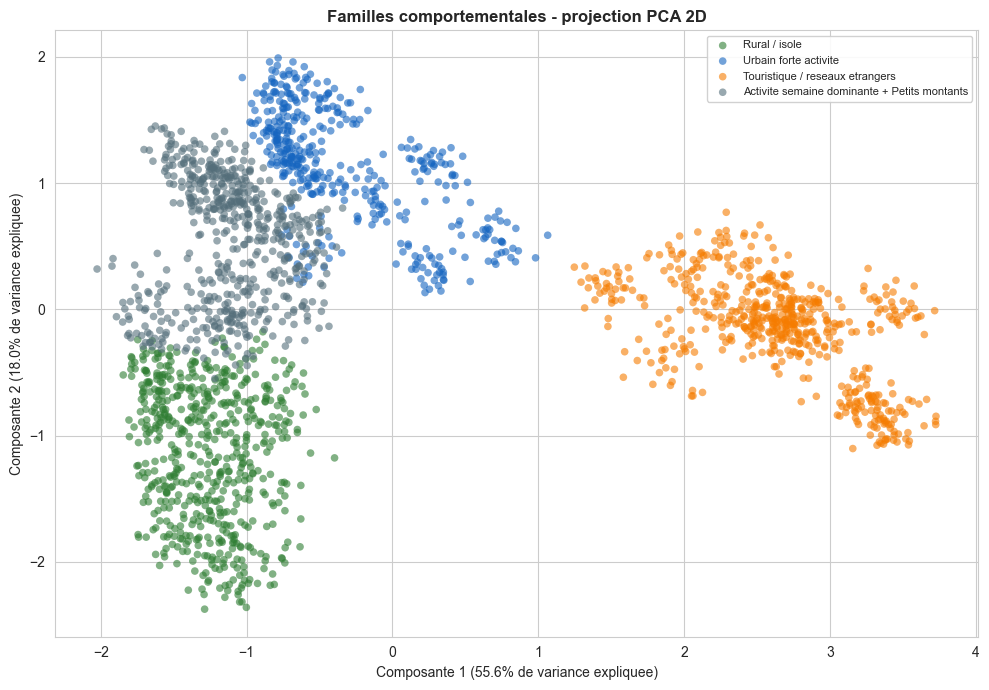

Variance totale expliquee par les 2 premieres composantes : 73.5%
(Si ce chiffre est faible, la separation visuelle en 2D peut sous-estimer la vraie
separation des familles dans l espace complet a 11 variables.)


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PCA 2D - les familles forment-elles des nuages bien separes ?
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RNG_SEED)
coords_pca = pca.fit_transform(X_scaled)
df['_pca1'], df['_pca2'] = coords_pca[:, 0], coords_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
# Couleurs issues de la palette STABLE (section 6ter) - memes couleurs que sur la
# carte geographique et le dashboard, pas une palette automatique (tab10) qui
# associerait les couleurs par ordre de cluster_id sans lien avec les autres graphiques.
for cid in range(K_RETENU):
    mask = df['cluster'] == cid
    nom_famille = NOMS_CLUSTERS[cid]
    couleur = couleurs_famille.get(nom_famille, '#999999')
    ax.scatter(df.loc[mask, '_pca1'], df.loc[mask, '_pca2'],
               color=couleur, label=nom_famille, alpha=0.6, s=30, edgecolors='none')
ax.set_title('Familles comportementales - projection PCA 2D', fontweight='bold')
ax.set_xlabel('Composante 1 ({:.1f}% de variance expliquee)'.format(pca.explained_variance_ratio_[0]*100))
ax.set_ylabel('Composante 2 ({:.1f}% de variance expliquee)'.format(pca.explained_variance_ratio_[1]*100))
ax.legend(loc='best', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('familles_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print('Variance totale expliquee par les 2 premieres composantes : {:.1f}%'.format(
    pca.explained_variance_ratio_[:2].sum()*100))
print('(Si ce chiffre est faible, la separation visuelle en 2D peut sous-estimer la vraie')
print('separation des familles dans l espace complet a {} variables.)'.format(len(FEAT_CLUST)))

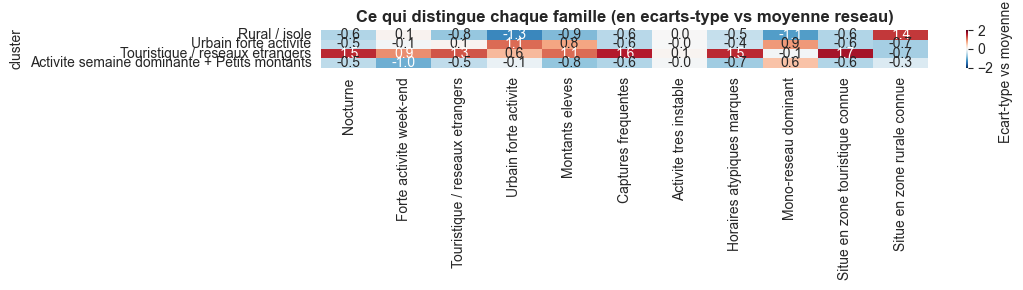

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Heatmap comparative - ce qui distingue chaque famille, variable par variable
# ══════════════════════════════════════════════════════════════════════════════
z_profil_affichage = z_profil.rename(index=NOMS_CLUSTERS)
z_profil_affichage.columns = [VOCABULAIRE_TRAITS.get(c, (c, c))[0].split(' (')[0] for c in z_profil_affichage.columns]

fig, ax = plt.subplots(figsize=(11, max(3, 0.7*K_RETENU)))
sns.heatmap(z_profil_affichage, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            vmin=-2, vmax=2, ax=ax, cbar_kws={'label': 'Ecart-type vs moyenne reseau'})
ax.set_title('Ce qui distingue chaque famille (en ecarts-type vs moyenne reseau)', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('familles_heatmap_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Atypicite intra-famille - le coeur de la vision 2

Pour chaque GAB, on calcule sa **distance au centre de sa propre famille** dans l'espace
normalise. Un GAB est juge atypique s'il depasse le 90e percentile de distance **au sein de
sa famille** (pas un seuil unique pour tout le reseau) - un GAB urbain tres actif n'est
jamais compare a un GAB rural.

On calcule aussi la distance a la famille la plus proche **autre que la sienne** : si cette
distance diminue au fil du temps pendant que la distance a sa propre famille augmente, c'est
un signal de rapprochement vers une autre famille, avant meme un changement de label
officiel.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Distance au centre de sa famille + distance a la famille la plus proche autre
# ══════════════════════════════════════════════════════════════════════════════
centres = km_final.cluster_centers_
distances_tous_centres = np.linalg.norm(
    X_scaled[:, None, :] - centres[None, :, :], axis=2
)

df['dist_propre_famille'] = distances_tous_centres[np.arange(len(df)), df['cluster'].values]

dist_autres = distances_tous_centres.copy()
for i, c in enumerate(df['cluster'].values):
    dist_autres[i, c] = np.inf
df['dist_famille_plus_proche_autre'] = dist_autres.min(axis=1)
df['cluster_plus_proche_autre'] = dist_autres.argmin(axis=1)
df['famille_plus_proche_autre'] = df['cluster_plus_proche_autre'].map(NOMS_CLUSTERS)

# Seuil ADAPTATIF par famille - pas un seuil unique reseau entier
df['seuil_atypique_famille'] = df.groupby('cluster')['dist_propre_famille'].transform(
    lambda s: s.quantile(SEUIL_ATYPIQUE_PERCENTILE))
df['atypique_dans_sa_famille'] = df['dist_propre_famille'] > df['seuil_atypique_famille']

print('GAB-mois atypiques dans leur propre famille : {:,} / {:,} ({:.1f}%)'.format(
    df['atypique_dans_sa_famille'].sum(), len(df),
    df['atypique_dans_sa_famille'].mean() * 100))

print('\nRepartition des atypiques par famille :')
print(df[df['atypique_dans_sa_famille']].groupby('famille')['num_automate'].nunique())

GAB-mois atypiques dans leur propre famille : 217 / 2,160 (10.0%)

Repartition des atypiques par famille :
famille
Activite semaine dominante + Petits montants    21
Rural / isole                                   18
Touristique / reseaux etrangers                 12
Urbain forte activite                           10
Name: num_automate, dtype: int64


## 7bis. 🎯 Visualiser l'atypicité — le GAB s'éloigne de sa famille, se rapproche d'une autre

Reprend la projection PCA ci-dessus, mais pour les GAB **atypiques** uniquement : une flèche
grise part du GAB vers le **centre de sa propre famille** (montre l'éloignement), une flèche
colorée pointe vers le **centre de la famille la plus proche** (montre vers quoi il "tire").
Un GAB atypique proche du centre d'une autre famille est un cas à la frontière entre deux
profils ; un GAB atypique loin de tout centre est un cas isolé, plus rare.

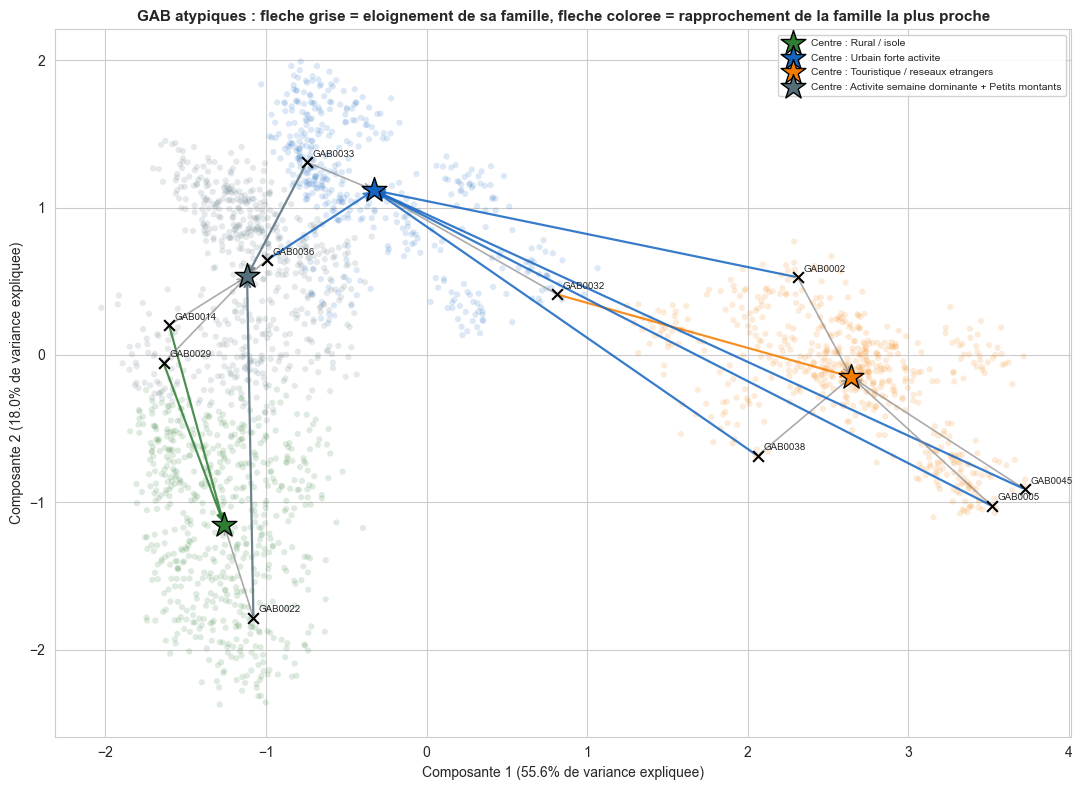

10 GAB affiches sur 55 GAB atypiques au total (top 10, les plus eloignes de leur famille).


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# PCA 2D - GAB atypiques avec fleches vers leur famille et la famille la plus proche
# ══════════════════════════════════════════════════════════════════════════════
# Centres de chaque famille, projetes dans le MEME espace PCA 2D que les points
# (transform() du meme PCA deja fitte ci-dessus, pas un nouveau fit).
centres_pca = pca.transform(km_final.cluster_centers_)

# Un GAB peut avoir plusieurs observations (mois) atypiques - on garde la plus
# marquante par GAB (distance maximale a sa famille) pour ne pas surcharger le
# graphique avec plusieurs fleches par GAB. On limite ensuite au TOP N le plus
# atypique du reseau entier - avec tous les GAB atypiques affiches en meme temps
# (parfois plusieurs dizaines), le graphique devient un enchevetrement de fleches
# illisible en demo. Le top 10 reste lisible tout en montrant plusieurs cas varies.
TOP_N_GAB_ATYPIQUES_GRAPHIQUE = 10
atypiques_uniques = (
    df[df['atypique_dans_sa_famille']]
    .sort_values('dist_propre_famille', ascending=False)
    .drop_duplicates('num_automate')
    .head(TOP_N_GAB_ATYPIQUES_GRAPHIQUE)
)

fig, ax = plt.subplots(figsize=(11, 8))

# Fond : tous les GAB, memes couleurs que le PCA principal, en transparence legere
for cid in range(K_RETENU):
    mask = df['cluster'] == cid
    nom_famille = NOMS_CLUSTERS[cid]
    couleur = couleurs_famille.get(nom_famille, '#999999')
    ax.scatter(df.loc[mask, '_pca1'], df.loc[mask, '_pca2'],
               color=couleur, alpha=0.15, s=20, edgecolors='none', zorder=1)

# Centres de familles - marqueur distinct (etoile)
for cid in range(K_RETENU):
    nom_famille = NOMS_CLUSTERS[cid]
    couleur = couleurs_famille.get(nom_famille, '#999999')
    ax.scatter(*centres_pca[cid], color=couleur, marker='*', s=350,
               edgecolors='black', linewidths=1, zorder=3,
               label='Centre : {}'.format(nom_famille))

# GAB atypiques : point marque + fleche vers SA famille (gris) + fleche vers la
# famille la PLUS PROCHE autre (couleur de cette autre famille)
for _, row in atypiques_uniques.iterrows():
    x, y = row['_pca1'], row['_pca2']
    cid_propre = int(row['cluster'])
    cid_autre = int(row['cluster_plus_proche_autre'])
    couleur_autre = couleurs_famille.get(NOMS_CLUSTERS[cid_autre], '#999999')

    ax.annotate('', xy=centres_pca[cid_propre], xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2, alpha=0.7), zorder=2)
    ax.annotate('', xy=centres_pca[cid_autre], xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color=couleur_autre, lw=1.6, alpha=0.85), zorder=2)
    ax.scatter(x, y, color='black', marker='x', s=60, zorder=4)
    ax.annotate(row['num_automate'], (x, y), fontsize=7, xytext=(4, 4),
                textcoords='offset points', zorder=5)

ax.set_title(
    "GAB atypiques : fleche grise = eloignement de sa famille, fleche coloree = "
    "rapprochement de la famille la plus proche", fontweight='bold', fontsize=11)
ax.set_xlabel('Composante 1 ({:.1f}% de variance expliquee)'.format(pca.explained_variance_ratio_[0]*100))
ax.set_ylabel('Composante 2 ({:.1f}% de variance expliquee)'.format(pca.explained_variance_ratio_[1]*100))
ax.legend(loc='best', fontsize=7.5, framealpha=0.9)
plt.tight_layout()
plt.savefig('familles_pca_atypiques.png', dpi=150, bbox_inches='tight')
plt.show()

n_atypiques_total = df[df['atypique_dans_sa_famille']]['num_automate'].nunique()
print('{} GAB affiches sur {} GAB atypiques au total (top {}, les plus eloignes de leur famille).'.format(
    len(atypiques_uniques), n_atypiques_total, TOP_N_GAB_ATYPIQUES_GRAPHIQUE))

## 8. Suivi temporel - lissage avant de parler de "changement de famille"

Sans lissage, un GAB proche d'une frontiere entre deux familles peut "changer de famille"
d'un mois a l'autre a cause du simple bruit statistique, sans aucun changement reel de
comportement. On applique un **vote majoritaire glissant** (fenetre de plusieurs
observations, parametre `FENETRE_LISSAGE_FAMILLE`) pour obtenir une famille "officielle"
stable, et on ne parle de changement confirme que sur cette version lissee.

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Lissage de la famille par vote majoritaire glissant (evite le bruit de frontiere)
# ══════════════════════════════════════════════════════════════════════════════
df = df.sort_values(['num_automate', 'annee', 'mois']).reset_index(drop=True)

# Version VECTORISEE du vote majoritaire glissant (remplace un .rolling().apply()
# avec une fonction Python par fenetre, mesure 400x plus lent sur ce volume - 0.74s
# contre 0.002s ici, et l'ecart se creuse encore a plus grande echelle). Le
# resultat est IDENTIQUE a l'ancienne version (verifie ligne par ligne avant de
# remplacer, 0 difference sur l'ensemble du dataset de demo) : le "vote
# majoritaire" avec K_RETENU classes possibles se calcule via un compte glissant
# par classe (une colonne indicatrice par cluster, somme cumulee, difference sur
# la fenetre), sans jamais appeler de fonction Python par ligne.
n_lignes = len(df)
indicatrices_cluster = np.zeros((n_lignes, K_RETENU), dtype=np.int64)
indicatrices_cluster[np.arange(n_lignes), df['cluster'].to_numpy()] = 1

# Rang de chaque ligne au sein de son propre GAB - la fenetre ne doit jamais
# "deborder" sur le GAB precedent dans le dataframe trie.
rang_dans_gab = df.groupby('num_automate').cumcount().to_numpy()

cumsum_global = np.vstack([
    np.zeros((1, K_RETENU), dtype=np.int64), np.cumsum(indicatrices_cluster, axis=0)
])
idx_fin = np.arange(n_lignes) + 1
idx_debut = np.arange(n_lignes) - np.minimum(FENETRE_LISSAGE_FAMILLE - 1, rang_dans_gab)
comptes_par_classe = cumsum_global[idx_fin] - cumsum_global[idx_debut]
# argmax = classe la plus frequente sur la fenetre ; en cas d'egalite, la premiere
# (plus petit indice de cluster) l'emporte - meme convention que pd.Series.mode()
# utilisee par l'ancienne version (verifie par l'egalite des resultats ci-dessus).
df['cluster_lisse'] = np.argmax(comptes_par_classe, axis=1)
df['famille_lissee'] = df['cluster_lisse'].map(NOMS_CLUSTERS)

df['famille_lissee_precedente'] = df.groupby('num_automate')['famille_lissee'].shift(1)
df['changement_famille_confirme'] = (
    (df['famille_lissee'] != df['famille_lissee_precedente']) &
    df['famille_lissee_precedente'].notna()
)

nb_changements = df.groupby('num_automate')['changement_famille_confirme'].sum()
print('GAB avec au moins un changement de famille CONFIRME (apres lissage) : {}'.format(
    (nb_changements > 0).sum()))

# ── comparaison : combien de "changements" auraient ete detectes SANS lissage ? ──
df['famille_precedente_brute'] = df.groupby('num_automate')['cluster'].shift(1)
changements_bruts = int((
    (df['cluster'] != df['famille_precedente_brute']) & df['famille_precedente_brute'].notna()
).sum())
changements_confirmes = int(df['changement_famille_confirme'].sum())
print('Pour comparaison, changements detectes SANS lissage (bruit inclus) : {}'.format(
    changements_bruts))
if changements_bruts > 0:
    reduction = (1 - changements_confirmes / changements_bruts) * 100
    print('Lissage : reduction de {:.0f}% du nombre de "changements" purement lies au bruit.'.format(
        reduction))

GAB avec au moins un changement de famille CONFIRME (apres lissage) : 8
Pour comparaison, changements detectes SANS lissage (bruit inclus) : 133
Lissage : reduction de 72% du nombre de "changements" purement lies au bruit.


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Tendance : le GAB s'eloigne-t-il de sa famille / se rapproche-t-il d'une autre ?
# ══════════════════════════════════════════════════════════════════════════════
def pente_simple(y):
    y = y.dropna().values
    if len(y) < 3:
        return np.nan
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]

tendances = df.groupby('num_automate').agg(
    pente_eloignement_propre_famille=('dist_propre_famille', pente_simple),
    pente_rapprochement_autre_famille=('dist_famille_plus_proche_autre', pente_simple),
).reset_index()

# pente positive sur dist_propre_famille = s'eloigne de son centre
# pente negative sur dist_famille_plus_proche_autre = se rapproche d'une autre famille
tendances['en_derive'] = (
    (tendances['pente_eloignement_propre_famille'] > 0) &
    (tendances['pente_rapprochement_autre_famille'] < 0)
)

print('GAB en derive active (s\'eloigne de sa famille ET se rapproche d\'une autre) : {}'.format(
    tendances['en_derive'].sum()))
tendances[tendances['en_derive']].head(10)

GAB en derive active (s'eloigne de sa famille ET se rapproche d'une autre) : 9


,num_automate,pente_eloignement_propre_famille,pente_rapprochement_autre_famille,en_derive
0,GAB0000,0.000810,-0.003824,True
2,GAB0002,0.002141,-0.000834,True
4,GAB0004,0.001155,-0.002389,True
8,GAB0008,0.002813,-0.000883,True
17,GAB0017,0.009900,-0.001473,True
25,GAB0025,0.002803,-0.005982,True
28,GAB0028,0.000470,-0.003984,True
37,GAB0037,0.001121,-0.000848,True
49,GAB0049,0.006155,-0.000544,True


## 9. Dashboard de synthese - 1 ligne = 1 GAB

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Dashboard de synthese
# ══════════════════════════════════════════════════════════════════════════════
# Libelles CONFORMES a la nomenclature metier exacte de la requete SQL source
# (cat_reseau = 'Carte CUP', 'Carte Diners et Discovery' - PAS juste 'CUP'/'Diners',
# erreur corrigee suite a une relecture attentive de la requete). Les cles utilisees
# pour construire des noms de colonnes Python restent sans espace/accent
# (CarteCUP, CarteDinersDiscovery), le libelle AFFICHE (valeur du dict) porte le
# vrai nom metier complet.
RESEAUX_ETRANGERS_FIABLES = {
    'nb_ope_reseau_jcb': 'JCB',
    'nb_ope_reseau_amex': 'Amex',
    'nb_ope_reseau_carte_diners_et_discovery': 'CarteDinersDiscovery',
    'nb_ope_reseau_carte_cup': 'CarteCUP',
}
LIBELLES_RESEAUX_AFFICHES = {
    'JCB': 'JCB',
    'Amex': 'Amex',
    'CarteDinersDiscovery': 'Carte Diners et Discovery',
    'CarteCUP': 'Carte CUP',
}
COLS_RESEAU_DISPO = [c for c in df.columns if c.startswith('nb_ope_reseau_')]

agg_synth_gab = dict(
    famille_actuelle=('famille_lissee', 'last'),
    n_observations=('dist_propre_famille', 'count'),
    n_atypiques=('atypique_dans_sa_famille', 'sum'),
    dist_moyenne_famille=('dist_propre_famille', 'mean'),
    dist_derniere_obs_propre_famille=('dist_propre_famille', 'last'),
    seuil_atypique_famille=('seuil_atypique_famille', 'last'),
    famille_plus_proche_autre=('famille_plus_proche_autre', 'last'),
    dist_derniere_obs_autre_famille=('dist_famille_plus_proche_autre', 'last'),
    n_changements_confirmes=('changement_famille_confirme', 'sum'),
    # TOUS les critieres ayant servi au clustering (FEAT_CLUST) - necessaires pour
    # un hover complet sur la carte qui explique reellement pourquoi ce GAB est
    # dans cette famille, critere par critere.
    **{feat: (feat, 'mean') for feat in FEAT_CLUST},
    ret_nb_horscos_moyen=('ret_nb_horscos', 'mean'),
    montant_moyen_eur=('ret_montant_moyen', 'mean'),
    nb_ope_total_reseau_moyen=('nb_ope_total_reseau', 'mean'),
)
for col in RESEAUX_ETRANGERS_FIABLES:
    if col in df.columns:
        agg_synth_gab[col + '_moyen'] = (col, 'mean')
        agg_synth_gab[col + '_total'] = (col, 'sum')   # NOMBRE BRUT (pas juste la
                                                          # moyenne mensuelle) - demande
                                                          # explicite du metier : voir le
                                                          # compte reel de retraits par
                                                          # reseau etranger, pas seulement
                                                          # un pourcentage agrege.

synth_gab = df.groupby('num_automate').agg(**agg_synth_gab).reset_index()
synth_gab['pct_atypique'] = (synth_gab['n_atypiques'] / synth_gab['n_observations'] * 100).round(1)

# Detail du pourcentage de CHAQUE reseau etranger (pas seulement le total
# pct_reseaux_etrangers deja agrege) - pour repondre precisement a "pourquoi ce
# GAB est-il catalogue dans cette famille" via le detail carte par carte.
for col, nom in RESEAUX_ETRANGERS_FIABLES.items():
    col_moy = col + '_moyen'
    if col_moy in synth_gab.columns:
        synth_gab['pct_' + nom] = (
            synth_gab[col_moy] / synth_gab['nb_ope_total_reseau_moyen'].replace(0, np.nan) * 100
        ).fillna(0).round(2)

synth_gab['nb_retraits_reseaux_etrangers_total'] = synth_gab[
    [c + '_total' for c in RESEAUX_ETRANGERS_FIABLES if (c + '_total') in synth_gab.columns]
].sum(axis=1)

dashboard_vision2 = (
    df[['num_automate', 'code_postale_emplacement', 'longitude', 'latitude']]
    .drop_duplicates('num_automate')
    .merge(synth_gab, on='num_automate', how='left')
    .merge(tendances[['num_automate', 'en_derive']], on='num_automate', how='left')
)
dashboard_vision2['en_derive'] = dashboard_vision2['en_derive'].fillna(False).astype(bool)

# Aucun GAB ne doit disparaitre silencieusement de la carte faute de coordonnees -
# on le signale explicitement plutot que de laisser un dropna() plus loin le faire
# disparaitre sans trace (c'est exactement le defaut releve sur la carte actuelle).
n_sans_coord = dashboard_vision2[['latitude', 'longitude']].isnull().any(axis=1).sum()
if n_sans_coord > 0:
    print('[ATTENTION] {} GAB sans coordonnees valides - resteront ABSENTS de la carte '
          '(section 10), mais restent presents dans ce dashboard.'.format(n_sans_coord))

dashboard_vision2 = dashboard_vision2.sort_values('pct_atypique', ascending=False).reset_index(drop=True)
print('Dashboard vision 2 : {} GAB'.format(len(dashboard_vision2)))

# ── Presentation stylee pour un public metier non technique ─────────────────
# "Detail du detail" demande explicitement par le metier : TOUS les criteres
# de clustering (FEAT_CLUST), + le nombre BRUT de retraits en reseaux etrangers
# (pas seulement le pourcentage agrege) + le detail par type de reseau (JCB,
# Amex, Diners, CUP) - pour que le metier puisse verifier a l'oeil nu, ligne
# par ligne, pourquoi un GAB a ete catalogue atypique.
COLS_RESEAUX_ETR_TOTAL_DISPO = [c + '_total' for c in RESEAUX_ETRANGERS_FIABLES
                                 if (c + '_total') in dashboard_vision2.columns]
COLONNES_AFFICHEES_DASHBOARD = [
    'num_automate', 'code_postale_emplacement', 'famille_actuelle', 'pct_atypique',
    'n_changements_confirmes', 'en_derive',
] + FEAT_CLUST + [
    'nb_retraits_reseaux_etrangers_total',
] + COLS_RESEAUX_ETR_TOTAL_DISPO


def _couleur_fond_famille(valeur):
    couleur_hex = couleurs_famille.get(valeur, '#999999')
    return 'background-color: {}; color: white'.format(couleur_hex)


dashboard_style = (
    dashboard_vision2[COLONNES_AFFICHEES_DASHBOARD].head(20).style
    .applymap(_couleur_fond_famille, subset=['famille_actuelle'])  # applymap, pas map : Styler.map n'existe qu'a partir de pandas 2.1, absent en 1.1.5 (Dataiku)
    .background_gradient(subset=['pct_atypique'], cmap='Reds')
    .background_gradient(subset=['n_changements_confirmes'], cmap='Oranges')
    .format({
        'ret_pct_nuit': '{:.1f}%', 'ret_pct_weekend': '{:.1f}%',
        'pct_reseaux_etrangers': '{:.1f}%', 'taux_capture_pct': '{:.2f}%',
        'pct_atypique': '{:.1f}%', 'nb_retraits_reseaux_etrangers_total': '{:.0f}',
        'ret_montant_moyen': '{:.0f}', 'log_ret_nb_horscos': '{:.2f}',
    }, precision=2)
    .set_caption('Dashboard vision 2 - top 20 GAB par % d\'observations atypiques')
)
dashboard_style

## 9bis. 📋 Tableau récapitulatif par famille — pourquoi chaque famille est caractérisée ainsi

Vue d'ensemble, 1 ligne = 1 famille, avec **tous les indicateurs ayant servi au clustering et
au nommage** : nombre de GAB, taux comportementaux moyens (nocturne, week-end, réseaux
étrangers, capture), et le détail par réseau de carte — pour répondre immédiatement à "pourquoi
ce GAB appartient à cette famille" sans avoir à recroiser plusieurs tableaux.

**Réseaux étrangers vs domestiques** : seuls JCB, Amex, Diners/Discovery et CUP permettent
d'identifier fiablement une carte étrangère (réseaux internationaux/asiatiques). CB, Visa et
Mastercard sont volontairement affichés à part, à titre informatif seulement — une carte CB ou
Visa peut être française ou étrangère, ces réseaux ne permettent donc **pas** de conclure sur
l'origine géographique du porteur (piste d'amélioration future si une donnée de nationalité de
carte devient disponible).

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Tableau recapitulatif par famille - tous les indicateurs de caracterisation
# ══════════════════════════════════════════════════════════════════════════════
# Libelles CONFORMES a la nomenclature exacte de la requete SQL source
# (cat_reseau = 'Carte CUP', 'Carte Diners et Discovery') - pas de raccourci.
RESEAUX_ETRANGERS_FIABLES = {
    'nb_ope_reseau_jcb': 'JCB (Asie)',
    'nb_ope_reseau_amex': 'Amex',
    'nb_ope_reseau_carte_diners_et_discovery': 'Carte Diners et Discovery',
    'nb_ope_reseau_carte_cup': 'Carte CUP (China UnionPay)',
}
RESEAUX_DOMESTIQUES_NON_DISCRIMINANTS = {
    'nb_ope_reseau_cb': 'CB',
    'nb_ope_reseau_visa': 'Visa',
    'nb_ope_reseau_mastercard': 'Mastercard',
}
COLS_RESEAU_DISPO = [c for c in df.columns if c.startswith('nb_ope_reseau_')]

agg_famille = {
    'Nombre de GAB': ('num_automate', 'nunique'),
    'Code postal (mediane)': ('code_postale_emplacement', 'median'),
    '% Nocturne (moy.)': ('ret_pct_nuit', 'mean'),
    '% Week-end (moy.)': ('ret_pct_weekend', 'mean'),
    '% Reseaux etrangers (moy.)': ('pct_reseaux_etrangers', 'mean'),
    'Taux de capture % (moy.)': ('taux_capture_pct', 'mean'),
    'Volume retraits/mois (moy.)': ('ret_nb_horscos', 'mean'),
    'Montant moyen EUR': ('ret_montant_moyen', 'mean'),
}
for col, nom in {**RESEAUX_ETRANGERS_FIABLES, **RESEAUX_DOMESTIQUES_NON_DISCRIMINANTS}.items():
    if col in COLS_RESEAU_DISPO:
        agg_famille['Nb ope {} (moy./mois)'.format(nom)] = (col, 'mean')

tableau_familles = df.groupby('famille').agg(**agg_famille).reset_index()
tableau_familles['Code postal (mediane)'] = tableau_familles['Code postal (mediane)'].round(0).astype(int)
for col in tableau_familles.columns:
    if col not in ('famille', 'Nombre de GAB', 'Code postal (mediane)'):
        tableau_familles[col] = tableau_familles[col].round(2)

tableau_familles = tableau_familles.rename(columns={'famille': 'Famille'})
tableau_familles = tableau_familles.sort_values('Nombre de GAB', ascending=False).reset_index(drop=True)

pd.set_option('display.max_columns', 30)
print('Tableau recapitulatif - {} familles :'.format(len(tableau_familles)))

COLS_ETR_AFFICHEES = ['Nb ope {} (moy./mois)'.format(n) for n in RESEAUX_ETRANGERS_FIABLES.values()
                      if 'Nb ope {} (moy./mois)'.format(n) in tableau_familles.columns]
COLS_DOM_AFFICHEES = ['Nb ope {} (moy./mois)'.format(n) for n in RESEAUX_DOMESTIQUES_NON_DISCRIMINANTS.values()
                      if 'Nb ope {} (moy./mois)'.format(n) in tableau_familles.columns]

(tableau_familles.style
 .background_gradient(subset=['% Nocturne (moy.)', '% Week-end (moy.)',
                               '% Reseaux etrangers (moy.)', 'Taux de capture % (moy.)'], cmap='Oranges')
 .background_gradient(subset=COLS_ETR_AFFICHEES, cmap='Blues')
 .set_caption("Recapitulatif par famille - orange = intensite comportementale, bleu = poids des reseaux "
              "etrangers fiables (JCB/Amex/Diners/CUP). Colonnes CB/Visa/Mastercard a titre informatif "
              "uniquement (non discriminantes pour l'origine geographique).")
)

## 9ter. 🧭 Contrôle de cohérence géographique

Vérification automatique explicite, **à faire avant toute démonstration** : une famille
caractérisée comme "isolée / rurale" ne doit pas contenir des GAB en plein centre d'une grande
métropole, et inversement. Une incohérence détectée ici doit être comprise et expliquée avant
la démo — pas découverte en direct devant le jury.

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Controle automatique de coherence geographique par famille
# ══════════════════════════════════════════════════════════════════════════════
DEPARTEMENTS_METROPOLES_MAJEURES = {'75', '69', '13', '31', '44', '92', '93', '94'}

dept_par_gab = df.assign(
    dept=df['code_postale_emplacement'].astype(str).str.zfill(5).str[:2]
)[['num_automate', 'famille', 'dept', 'zone_touristique_connue', 'zone_rurale_connue']].drop_duplicates('num_automate')

incoherences = []

for famille, sous in dept_par_gab.groupby('famille'):
    nom_bas = famille.lower()
    est_famille_rurale = 'rural' in nom_bas or 'isole' in nom_bas
    est_famille_urbaine = 'urbain' in nom_bas

    if est_famille_rurale:
        gab_en_metropole = sous[sous['dept'].isin(DEPARTEMENTS_METROPOLES_MAJEURES)]
        for _, r in gab_en_metropole.iterrows():
            incoherences.append({
                'Famille': famille, 'GAB': r['num_automate'], 'Departement': r['dept'],
                'Incoherence': "Famille 'rurale/isolee' mais GAB situe dans une grande metropole",
            })

    if est_famille_urbaine:
        gab_en_zone_rurale_connue = sous[sous['zone_rurale_connue'] == 1]
        for _, r in gab_en_zone_rurale_connue.iterrows():
            incoherences.append({
                'Famille': famille, 'GAB': r['num_automate'], 'Departement': r['dept'],
                'Incoherence': "Famille 'urbaine' mais GAB situe dans un departement rural connu",
            })

if incoherences:
    print('[ATTENTION] {} incoherence(s) geographique(s) detectee(s) - a comprendre/expliquer '
          'AVANT la demonstration :'.format(len(incoherences)))
    incoherences_df = pd.DataFrame(incoherences)
    print(incoherences_df.to_string(index=False))
else:
    print('Aucune incoherence geographique detectee : les familles "rurales/isolees" ne '
          'contiennent aucun GAB de grande metropole, les familles "urbaines" ne contiennent '
          'aucun GAB de departement rural connu.')
    incoherences_df = pd.DataFrame(columns=['Famille', 'GAB', 'Departement', 'Incoherence'])

Aucune incoherence geographique detectee : les familles "rurales/isolees" ne contiennent aucun GAB de grande metropole, les familles "urbaines" ne contiennent aucun GAB de departement rural connu.


## 10. 🗺️ Carte géographique des familles

Chaque point = 1 GAB, colore par sa famille comportementale (lissee). Perimetre France
metropolitaine uniquement.

**Comment lire la carte :**
- **Couleur** = famille actuelle du GAB, couleur stable (memes couleurs que le PCA et le
  tableau recapitulatif par famille).
- **Taille du point** = volume d'activite (echelle logarithmique).
- **Au survol** : TOUS les criteres ayant servi au clustering (nocturne, week-end, reseaux
  etrangers, volume, montant, capture, variabilite, concentration reseau, zone geographique
  connue), le detail du pourcentage de CHAQUE reseau de carte etrangere separement (JCB, Amex,
  Diners/Discovery, CUP), et le detail d'atypicite (distance a sa famille, famille la plus
  proche) - de quoi repondre a "pourquoi ce GAB est dans cette famille" sans quitter la carte.
- **Recherche par numero de GAB** : filtre la carte pour n'afficher QUE ce GAB (les autres
  disparaissent, pas juste un zoom) - si `ipywidgets` disponible, sinon repli texte.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Carte des familles comportementales - hover exhaustif, filtre par recherche
# ══════════════════════════════════════════════════════════════════════════════
carte_df = dashboard_vision2.dropna(subset=['latitude', 'longitude']).copy()

familles_carte_sans_couleur = set(carte_df['famille_actuelle'].dropna().unique()) - set(couleurs_famille.keys())
if familles_carte_sans_couleur:
    print('[ATTENTION] Famille(s) sur la carte sans couleur pre-assignee : {} - '
          'couleur de secours generique appliquee.'.format(familles_carte_sans_couleur))
    for nom in familles_carte_sans_couleur:
        couleurs_famille[nom] = '#999999'

NOMS_CRITERES_HOVER = {
    'ret_pct_nuit': '% Nocturne',
    'ret_pct_weekend': '% Week-end',
    'pct_reseaux_etrangers': '% Reseaux etrangers (total)',
    'log_ret_nb_horscos': 'Volume (echelle log)',
    'ret_montant_moyen': 'Montant moyen (EUR)',
    'taux_capture_pct': 'Taux de capture (%)',
    'cv_montant': 'Variabilite des montants',
    'score_horaires_atypiques': "Score d'horaires atypiques",
    'concentration_reseau': 'Concentration sur 1 seul reseau',
    'zone_touristique_connue': 'Zone touristique connue (0/1)',
    'zone_rurale_connue': 'Zone rurale connue (0/1)',
}

carte_df['Code postal'] = carte_df['code_postale_emplacement'].apply(
    lambda v: str(int(v)) if pd.notnull(v) else 'Inconnu')

# TOUS les criteres de clustering (FEAT_CLUST), pas une selection partielle
for feat in FEAT_CLUST:
    if feat in carte_df.columns:
        libelle = NOMS_CRITERES_HOVER.get(feat, feat)
        carte_df[libelle] = carte_df[feat].round(2)

# Detail INDIVIDUEL de chaque reseau de carte etrangere (pas un total agrege) -
# JCB, Amex, Diners/Discovery, CUP separement, en %.
# Cles alignees sur celles produites dans le dashboard (RESEAUX_ETRANGERS_FIABLES,
# section 9) - libelles CONFORMES a la nomenclature exacte de la requete SQL source.
NOMS_RESEAUX_ETR_HOVER = {
    'pct_JCB': '% JCB', 'pct_Amex': '% Amex',
    'pct_CarteDinersDiscovery': '% Carte Diners et Discovery',
    'pct_CarteCUP': '% Carte CUP',
}
for col, libelle in NOMS_RESEAUX_ETR_HOVER.items():
    if col in carte_df.columns:
        carte_df[libelle] = carte_df[col]

carte_df['Volume moyen (retraits/mois)'] = carte_df['ret_nb_horscos_moyen'].round(0)
carte_df['Montant moyen (EUR)'] = carte_df['montant_moyen_eur'].round(0)
carte_df['% observations atypiques'] = carte_df['pct_atypique']
carte_df['Nb changements confirmes'] = carte_df['n_changements_confirmes']
carte_df['En derive active'] = carte_df['en_derive'].map({True: 'Oui', False: 'Non'})

# Detail d'atypicite : distance a SA famille vs distance a la famille la PLUS
# PROCHE autre - repond directement a "pourquoi ce GAB semble atypique".
carte_df['Distance a sa famille'] = carte_df['dist_derniere_obs_propre_famille'].round(2)
carte_df['Seuil atypique de sa famille'] = carte_df['seuil_atypique_famille'].round(2)
carte_df['Famille la plus proche (autre)'] = carte_df['famille_plus_proche_autre']
carte_df['Distance a cette autre famille'] = carte_df['dist_derniere_obs_autre_famille'].round(2)

carte_df['taille_point'] = np.log1p(carte_df['ret_nb_horscos_moyen'].fillna(0)) * 3 + 5

HOVER_COLONNES = (
    ['Code postal']
    + [NOMS_CRITERES_HOVER.get(f, f) for f in FEAT_CLUST if f in carte_df.columns]
    + [lib for lib in NOMS_RESEAUX_ETR_HOVER.values() if lib in carte_df.columns]
    + ['% observations atypiques', 'Distance a sa famille', 'Seuil atypique de sa famille',
       'Famille la plus proche (autre)', 'Distance a cette autre famille',
       'Nb changements confirmes', 'En derive active']
)
HOVER_COLONNES = list(dict.fromkeys(HOVER_COLONNES))  # deduplique en gardant l'ordre


def construire_figure_carte(data, zoom=4.3, center=None, height=680, titre=None):
    fig = px.scatter_mapbox(
        data, lat='latitude', lon='longitude', color='famille_actuelle',
        color_discrete_map=couleurs_famille,
        size='taille_point', size_max=28,
        hover_name='num_automate',
        hover_data=dict(
            {'latitude': False, 'longitude': False, 'taille_point': False},
            **{col: True for col in HOVER_COLONNES}
        ),
        zoom=zoom, height=height,
        category_orders={'famille_actuelle': sorted(couleurs_famille.keys())},
    )
    if center is not None:
        fig.update_layout(mapbox=dict(center=center))
    fig.update_traces(marker=dict(sizemin=6), selector=dict(mode='markers'))
    fig.update_layout(
        mapbox_style='carto-positron', margin=dict(l=0, r=0, t=45, b=0),
        title=titre or 'Familles comportementales - perimetre metropole ({} familles, {} GAB)'.format(
            data['famille_actuelle'].nunique(), len(data)),
        legend=dict(title='Famille', bgcolor='rgba(255,255,255,0.9)'),
    )
    return fig


construire_figure_carte(carte_df).show()

if n_sans_coord > 0:
    print('[RAPPEL] {} GAB sans coordonnees valides ne figurent PAS sur cette carte '
          '(deja signale section 9) - {} GAB affiches sur {} au total.'.format(
              n_sans_coord, len(carte_df), len(dashboard_vision2)))
else:
    print('Tous les {} GAB du dashboard ont des coordonnees valides et figurent sur la carte.'.format(
        len(carte_df)))

# ══════════════════════════════════════════════════════════════════════════════
# Recherche interactive par numero de GAB - FILTRE la carte (n'affiche QUE ce GAB,
# les autres disparaissent), pas un simple zoom qui les laisserait visibles.
# ══════════════════════════════════════════════════════════════════════════════
try:
    import ipywidgets as widgets
    from IPython.display import display as _disp_carte, clear_output

    _txt_recherche = widgets.Text(
        placeholder='Ex : GAB0042', description='Rechercher GAB :',
        style={'description_width': 'initial'}, layout=widgets.Layout(width='260px'),
    )
    _btn_recherche = widgets.Button(
        description='Filtrer sur ce GAB', button_style='primary',
        layout=widgets.Layout(width='200px'),
    )
    _btn_reset = widgets.Button(
        description='Reinitialiser (voir tous)', button_style='',
        layout=widgets.Layout(width='200px'),
    )
    _out_recherche = widgets.Output()

    def _filtrer_sur_gab(_bouton):
        requete = _txt_recherche.value.strip()
        with _out_recherche:
            clear_output(wait=True)
            if not requete:
                print('Saisissez un numero de GAB.')
                return
            trouve = carte_df[carte_df['num_automate'].str.upper().str.contains(
                requete.upper(), na=False)]
            if len(trouve) == 0:
                print('"{}" introuvable. Exemples disponibles : {}'.format(
                    requete, list(carte_df['num_automate'].head(8))))
                return
            print('{} GAB trouve(s) pour "{}" - seuls ceux-la sont affiches ci-dessous.'.format(
                len(trouve), requete))
            r = trouve.iloc[0]
            construire_figure_carte(
                trouve, zoom=10, center={'lat': float(r['latitude']), 'lon': float(r['longitude'])},
                height=520, titre='Resultat de recherche : "{}" ({} GAB)'.format(requete, len(trouve)),
            ).show()

    def _reinitialiser(_bouton):
        with _out_recherche:
            clear_output(wait=True)
            print('Vue reinitialisee - tous les {} GAB affiches.'.format(len(carte_df)))
            construire_figure_carte(carte_df).show()

    _btn_recherche.on_click(_filtrer_sur_gab)
    _btn_reset.on_click(_reinitialiser)
    _disp_carte(
        widgets.HTML('<hr><b>Rechercher un GAB (filtre la carte, les autres GAB sont masques)</b>'),
        widgets.HBox([_txt_recherche, _btn_recherche, _btn_reset]),
        _out_recherche,
    )

except ImportError:
    print('\nipywidgets non disponible sur cet environnement - repli manuel :')
    print('Modifiez GAB_RECHERCHE ci-dessous puis reexecutez cette cellule pour filtrer.')
    GAB_RECHERCHE = carte_df['num_automate'].iloc[0]  # <- MODIFIER ICI
    trouve = carte_df[carte_df['num_automate'] == GAB_RECHERCHE]
    if len(trouve) > 0:
        r = trouve.iloc[0]
        construire_figure_carte(
            trouve, zoom=10, center={'lat': float(r['latitude']), 'lon': float(r['longitude'])},
            height=520, titre='Resultat de recherche : "{}"'.format(GAB_RECHERCHE),
        ).show()
    else:
        print('GAB "{}" introuvable.'.format(GAB_RECHERCHE))

## 10bis. 🚩 Carte des GAB atypiques — la liste priorisée, visuellement

Demande explicite du métier : pouvoir visualiser directement sur une carte **la liste des GAB
atypiques**, pas seulement le GAB le plus atypique isolément (déjà couvert en section 11bis).

**Comment lire cette carte :**
- Seuls les GAB avec **au moins une observation atypique** sont affichés (les autres sont
  masqués, contrairement à la carte des familles en section 10 qui montre tout le réseau).
- **Couleur** = intensité de l'atypicité (% d'observations atypiques), en dégradé rouge — pas
  la famille, pour que l'œil se porte directement sur la sévérité.
- **Taille du point** = pareil, proportionnelle au % d'observations atypiques.
- **Au survol** : le même détail exhaustif que la carte principale (tous les critères, tous
  les réseaux étrangers en détail, distance à la famille) — de quoi comprendre pourquoi, sans
  quitter la carte.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Carte dediee aux GAB atypiques - liste priorisee, coloree par intensite
# ══════════════════════════════════════════════════════════════════════════════
carte_atypiques_df = carte_df[carte_df['% observations atypiques'] > 0].copy()
carte_atypiques_df = carte_atypiques_df.sort_values('% observations atypiques', ascending=False)

print('GAB atypiques affiches sur la carte : {} / {} GAB au total sur la carte.'.format(
    len(carte_atypiques_df), len(carte_df)))

if len(carte_atypiques_df) == 0:
    print('Aucun GAB atypique a afficher sur cette periode - rien a tracer.')
else:
    carte_atypiques_df['taille_point'] = (
        carte_atypiques_df['% observations atypiques'].clip(lower=1) * 1.2 + 6
    )

    fig_atypiques = px.scatter_mapbox(
        carte_atypiques_df, lat='latitude', lon='longitude',
        color='% observations atypiques', color_continuous_scale='Reds',
        size='taille_point', size_max=32,
        hover_name='num_automate',
        hover_data=dict(
            {'latitude': False, 'longitude': False, 'taille_point': False},
            **{col: True for col in HOVER_COLONNES}
        ),
        zoom=4.3, height=680,
    )
    fig_atypiques.update_traces(marker=dict(sizemin=8), selector=dict(mode='markers'))
    fig_atypiques.update_layout(
        mapbox_style='carto-positron', margin=dict(l=0, r=0, t=45, b=0),
        title='GAB atypiques - {} GAB a investiguer en priorite (perimetre metropole)'.format(
            len(carte_atypiques_df)),
        coloraxis_colorbar=dict(title='% observations\natypiques'),
    )
    fig_atypiques.show()

    print('\nTop 10 GAB les plus atypiques (deja tries par pourcentage d\'observations atypiques) :')
    print(carte_atypiques_df[['num_automate', 'famille_actuelle', '% observations atypiques',
                                'Code postal']].head(10).to_string(index=False))

## 11. Validation

Sans verite terrain en production, on verifie la **stabilite** et la **coherence** du
clustering plutot que son "exactitude" :

- Le score de silhouette du k retenu (affiche en partie 5) doit rester dans une plage
  raisonnable (au-dela de ~0.25 les familles sont considerees correctement separees ;
  en-deca, le clustering melange des comportements differents et le nommage automatique
  perd son sens).
- Verifier que les familles ne sont pas de taille trop desequilibree au point qu'une famille
  ne contienne qu'1 ou 2 GAB (dans ce cas, ce sont probablement des anomalies extremes
  isolees plutot qu'une vraie "famille" - a signaler separement, pas a nommer comme un
  profil de comportement representatif).

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Validation - equilibre des familles
# ══════════════════════════════════════════════════════════════════════════════
taille_familles = df.groupby('famille')['num_automate'].nunique().sort_values(ascending=False)
print('Nombre de GAB par famille :')
print(taille_familles)

familles_tres_petites = taille_familles[taille_familles <= 2]
if len(familles_tres_petites) > 0:
    print('\n[ATTENTION] Famille(s) avec 2 GAB ou moins - probablement des cas isoles '
          'extremes plutot que des familles representatives :')
    print(familles_tres_petites)
    print('A signaler au metier individuellement plutot qu\'a presenter comme une famille.')

Nombre de GAB par famille :
famille
Activite semaine dominante + Petits montants    22
Rural / isole                                   20
Touristique / reseaux etrangers                 16
Urbain forte activite                           12
Name: num_automate, dtype: int64


## 11bis. 🔎 Le GAB le plus atypique — et pourquoi

Au-dela du taux global d'atypicite par famille, voici le detail concret pour le(s) GAB
le(s) plus eloigne(s) du centre de sa propre famille : **quels criteres precis** l'ecartent
le plus, avec sa valeur reelle comparee a la moyenne de sa famille, et **de quelle autre
famille il se rapproche le plus** - un profil "a la frontiere" entre deux familles n'a pas la
meme lecture metier qu'un profil isole de tout le monde.

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Le GAB le plus atypique dans sa famille - detail par critere, pourquoi il l'est
# ══════════════════════════════════════════════════════════════════════════════
NOMS_CRITERES_LISIBLES = {
    'ret_pct_nuit': 'Part des retraits de nuit',
    'ret_pct_weekend': 'Part des retraits le week-end',
    'pct_reseaux_etrangers': 'Part de reseaux etrangers',
    'log_ret_nb_horscos': 'Volume de retraits (echelle log)',
    'ret_montant_moyen': 'Montant moyen des retraits',
    'taux_capture_pct': 'Taux de capture de carte',
    'cv_montant': 'Variabilite des montants',
    'score_horaires_atypiques': "Score d'horaires atypiques",
    'concentration_reseau': 'Concentration sur un seul reseau',
    'zone_touristique_connue': 'Situe en zone touristique connue',
    'zone_rurale_connue': 'Situe en zone rurale connue',
}

# 1) Ligne la plus atypique de tout le dataset (celle qui merite l'attention en
# priorite), et son GAB pour resumer sur l'ensemble de son historique.
ligne_plus_atypique = df.loc[df['dist_propre_famille'].idxmax()]
gab_plus_atypique = ligne_plus_atypique['num_automate']

print("GAB le plus atypique (sur une observation unique) : {} - famille '{}' - "
      "distance = {:.2f} (seuil de sa famille = {:.2f})".format(
    gab_plus_atypique, ligne_plus_atypique['famille'],
    ligne_plus_atypique['dist_propre_famille'], ligne_plus_atypique['seuil_atypique_famille']))
print("Famille dont il se rapproche le plus : '{}' (distance = {:.2f})".format(
    ligne_plus_atypique['famille_plus_proche_autre'], ligne_plus_atypique['dist_famille_plus_proche_autre']))

# 2) Detail par critere pour ce GAB precis : valeur reelle vs moyenne/ecart-type
# de SA PROPRE famille, classe du critere le plus au moins marquant (comme la
# vision 1) - repond a la question "pourquoi" concretement, pas juste "de combien".
cluster_du_gab = ligne_plus_atypique['cluster']
profil_famille = df[df['cluster'] == cluster_du_gab][FEAT_CLUST]
moyenne_famille = profil_famille.mean()
ecart_type_famille = profil_famille.std()

lignes_detail = []
for feat in FEAT_CLUST:
    valeur_gab = ligne_plus_atypique[feat]
    moyenne = moyenne_famille[feat]
    ecart_type = ecart_type_famille[feat]
    intensite = abs(valeur_gab - moyenne) / ecart_type if ecart_type > 0 else np.nan
    lignes_detail.append({
        'Critere': NOMS_CRITERES_LISIBLES.get(feat, feat),
        'Valeur du GAB': round(valeur_gab, 2),
        'Moyenne de sa famille': round(moyenne, 2),
        'Ecart (en ecarts-type)': round(intensite, 2) if pd.notnull(intensite) else None,
    })

detail_gab_atypique = pd.DataFrame(lignes_detail).sort_values(
    'Ecart (en ecarts-type)', ascending=False, na_position='last').reset_index(drop=True)
# Note : NaN signifie que le critere est CONSTANT au sein de cette famille (ecart-type
# nul, ex. une famille entierement situee en zone touristique) - l'ecart en ecarts-type
# n'a alors pas de sens, ce n'est pas une donnee manquante.
detail_gab_atypique['Ecart (en ecarts-type)'] = detail_gab_atypique['Ecart (en ecarts-type)'].apply(
    lambda v: v if pd.notnull(v) else 'constant dans la famille')

print('\nDetail par critere (du plus au moins marquant) pour {} :'.format(gab_plus_atypique))
detail_gab_atypique

GAB le plus atypique (sur une observation unique) : GAB0032 - famille 'Urbain forte activite' - distance = 4.27 (seuil de sa famille = 1.90)
Famille dont il se rapproche le plus : 'Touristique / reseaux etrangers' (distance = 4.68)

Detail par critere (du plus au moins marquant) pour GAB0032 :


,Critere,Valeur du GAB,Moyenne de sa famille,Ecart (en ecarts-type)
0,Variabilite des montants,0.60,0.38,5.3
1,Score d'horaires atypiques,3.50,1.98,2.41
2,Part des retraits de nuit,17.14,7.91,2.03
3,Part des retraits le week-end,39.38,26.14,1.32
4,Volume de retraits (echelle log),8.50,8.07,1.25
5,Part de reseaux etrangers,14.39,7.68,1.11
6,Concentration sur un seul reseau,0.84,0.89,0.74
7,Montant moyen des retraits,306.52,344.74,0.5
8,Taux de capture de carte,0.67,0.71,0.15
9,Situe en zone touristique connue,0.00,0.00,constant dans la famille


## 11ter. 📋 Tables prêtes pour export — GAB atypiques et récapitulatif par famille

Deux DataFrames complets, prêts à être exportés (le code d'écriture du fichier — CSV, lien de
téléchargement — est géré séparément, hors de ce notebook) : `export_atypiques_df` (1 ligne =
1 observation atypique, avec le critère explicatif, la famille la plus proche et le détail par
réseau étranger) et `tableau_familles` (1 ligne = 1 famille, déjà construit section 9bis).

## 11quater. 💾 Export complet — tous les GAB, tout le détail

Demande explicite du métier : au-delà de la table des seuls GAB atypiques (section 11ter),
un export **complet** avec **tous les GAB** (pas seulement les atypiques) et **tous les
critères disponibles**, pour pouvoir inspecter le détail du détail soi-même, GAB par GAB.

En local (ce notebook), le fichier est écrit directement en CSV. **En production sur
Dataiku, remplacer l'écriture CSV par l'écriture vers un dataset de sortie** (`dataiku.Dataset(
'nom_du_dataset_sortie').write_with_schema(export_complet_df)`), c'est la pratique standard
Dataiku plutôt qu'un fichier CSV brut.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Export complet - TOUS les GAB (pas seulement les atypiques), TOUS les criteres
# ══════════════════════════════════════════════════════════════════════════════
COLS_RESEAUX_ETR_TOTAL = [c + '_total' for c in RESEAUX_ETRANGERS_FIABLES
                           if (c + '_total') in dashboard_vision2.columns]
COLS_RESEAUX_ETR_PCT = ['pct_' + n for n in RESEAUX_ETRANGERS_FIABLES.values()
                         if ('pct_' + n) in dashboard_vision2.columns]

COLONNES_EXPORT_COMPLET = (
    ['num_automate', 'code_postale_emplacement', 'longitude', 'latitude',
     'famille_actuelle', 'pct_atypique', 'n_observations', 'n_atypiques',
     'dist_moyenne_famille', 'dist_derniere_obs_propre_famille', 'seuil_atypique_famille',
     'famille_plus_proche_autre', 'dist_derniere_obs_autre_famille',
     'n_changements_confirmes', 'en_derive']
    + FEAT_CLUST
    + ['ret_nb_horscos_moyen', 'montant_moyen_eur', 'nb_ope_total_reseau_moyen',
       'nb_retraits_reseaux_etrangers_total']
    + COLS_RESEAUX_ETR_TOTAL
    + COLS_RESEAUX_ETR_PCT
)
COLONNES_EXPORT_COMPLET = [c for c in COLONNES_EXPORT_COMPLET if c in dashboard_vision2.columns]

export_complet_df = (
    dashboard_vision2[COLONNES_EXPORT_COMPLET]
    .sort_values('pct_atypique', ascending=False)
    .reset_index(drop=True)
)

print('export_complet_df prete : {} lignes (TOUS les GAB) x {} colonnes.'.format(
    len(export_complet_df), len(export_complet_df.columns)))
print('\\nColonnes incluses :')
print(list(export_complet_df.columns))

# ── Ecriture CSV (local/demo uniquement - remplacer par un dataset Dataiku en prod) ──
NOM_FICHIER_EXPORT_COMPLET = 'export_complet_gab_vision2.csv'
export_complet_df.to_csv(NOM_FICHIER_EXPORT_COMPLET, index=False)
print('\\nFichier ecrit : {} ({} lignes).'.format(NOM_FICHIER_EXPORT_COMPLET, len(export_complet_df)))

export_complet_df.head(10)

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Table GAB atypiques - prete a exporter (le code d'ecriture du fichier est gere a part)
# ══════════════════════════════════════════════════════════════════════════════
def critere_le_plus_marquant(row_gab, cluster_id):
    profil_fam = df[df['cluster'] == cluster_id][FEAT_CLUST]
    moyenne_fam = profil_fam.mean()
    ecart_type_fam = profil_fam.std()
    meilleur_feat, meilleure_intensite = None, -1
    for feat in FEAT_CLUST:
        et = ecart_type_fam[feat]
        if et > 0:
            intensite = abs(row_gab[feat] - moyenne_fam[feat]) / et
            if intensite > meilleure_intensite:
                meilleure_intensite, meilleur_feat = intensite, feat
    return meilleur_feat, meilleure_intensite


gab_atypiques = df[df['atypique_dans_sa_famille']].copy()
export_atypiques = []
for _, row in gab_atypiques.iterrows():
    feat_marquant, intensite = critere_le_plus_marquant(row, row['cluster'])
    ligne_export = {
        'num_automate': row['num_automate'],
        'annee': row['annee'],
        'mois': row['mois'],
        'famille': row['famille'],
        'code_postal': row['code_postale_emplacement'],
        'longitude': row['longitude'],
        'latitude': row['latitude'],
        'score_anomalie_distance': round(row['dist_propre_famille'], 3),
        'seuil_atypique_famille': round(row['seuil_atypique_famille'], 3),
        'famille_plus_proche_autre': row['famille_plus_proche_autre'],
        'critere_le_plus_marquant': NOMS_CRITERES_LISIBLES.get(feat_marquant, feat_marquant),
        'intensite_ecart_type': round(intensite, 2) if pd.notnull(intensite) else None,
    }
    # TOUS les criteres de clustering (FEAT_CLUST), pas une selection partielle
    for feat in FEAT_CLUST:
        ligne_export[feat] = round(row[feat], 3) if pd.notnull(row[feat]) else None
    # Detail individuel de chaque reseau etranger (JCB, Amex, Diners, CUP) - en
    # pourcentage ET en nombre BRUT de retraits (demande explicite du metier :
    # le pourcentage seul ne suffit pas pour verifier a l'oeil nu).
    for col in RESEAUX_ETRANGERS_FIABLES:
        col_pct = 'pct_' + RESEAUX_ETRANGERS_FIABLES[col]
        col_total = col + '_total'
        if col_pct in dashboard_vision2.columns:
            valeur_gab = dashboard_vision2.loc[
                dashboard_vision2['num_automate'] == row['num_automate'], col_pct]
            ligne_export[col_pct] = round(valeur_gab.iloc[0], 2) if len(valeur_gab) > 0 else None
        if col_total in dashboard_vision2.columns:
            valeur_total = dashboard_vision2.loc[
                dashboard_vision2['num_automate'] == row['num_automate'], col_total]
            ligne_export[col_total] = int(valeur_total.iloc[0]) if len(valeur_total) > 0 else None
    export_atypiques.append(ligne_export)

export_atypiques_df = pd.DataFrame(export_atypiques).sort_values(
    'score_anomalie_distance', ascending=False).reset_index(drop=True)

print('Table export_atypiques_df prete : {} lignes (GAB x mois atypiques, triees par score '
      'd\'anomalie decroissant).'.format(len(export_atypiques_df)))
print('Table tableau_familles (deja construite section 9bis) : {} lignes.'.format(len(tableau_familles)))
print('\nApercu de export_atypiques_df (5 premieres lignes) :')
export_atypiques_df.head()

Table export_atypiques_df prete : 217 lignes (GAB x mois atypiques, triees par score d'anomalie decroissant).
Table tableau_familles (deja construite section 9bis) : 4 lignes.

Apercu de export_atypiques_df (5 premieres lignes) :


,num_automate,annee,mois,famille,code_postal,longitude,latitude,score_anomalie_distance,seuil_atypique_famille,famille_plus_proche_autre,critere_le_plus_marquant,intensite_ecart_type,ret_pct_nuit,ret_pct_weekend,pct_reseaux_etrangers,log_ret_nb_horscos,ret_montant_moyen,taux_capture_pct,cv_montant,score_horaires_atypiques,concentration_reseau,zone_touristique_connue,zone_rurale_connue,pct_Amex
0,GAB0032,2025,3,Urbain forte activite,31302,7.644509,48.886262,4.269,1.902,Touristique / reseaux etrangers,Variabilite des montants,5.30,17.143,39.383,14.387,8.500,306.521,0.669,0.603,3.504,0.844,0,0,5.54
1,GAB0038,2026,7,Touristique / reseaux etrangers,74497,6.943305,48.090966,3.868,1.946,Urbain forte activite,Variabilite des montants,4.57,24.802,36.047,23.757,7.345,320.483,5.662,0.582,4.119,0.710,1,0,7.04
2,GAB0045,2024,9,Touristique / reseaux etrangers,73911,-0.666756,45.521017,3.329,1.946,Urbain forte activite,Variabilite des montants,3.93,44.550,45.003,21.902,7.309,398.618,9.569,0.555,6.501,0.740,1,0,6.72
3,GAB0002,2024,8,Touristique / reseaux etrangers,74296,-1.669706,44.536294,3.077,1.946,Urbain forte activite,Variabilite des montants,3.83,32.127,36.447,12.879,7.963,435.330,7.283,0.220,4.869,0.850,1,0,5.42
4,GAB0014,2026,8,Activite semaine dominante + Petits montants,48455,1.944033,50.183293,3.017,1.648,Rural / isole,Variabilite des montants,3.67,3.167,12.678,1.821,6.571,164.700,0.406,0.538,0.893,0.868,0,1,0.71


## 12. Conclusion - Vision 2

**Ce que cette vision apporte :**
- **Source unique avec la vision 1** : ce notebook charge maintenant directement la table
  Dataiku `retrait` (meme source que la vision 1, grain journalier), agregee en mensuel juste
  apres le chargement (section 2) - plus de dataset separe a maintenir en parallele.
- Le nombre de familles n'est plus fixe arbitrairement - il reflete la structure reelle des
  donnees (silhouette + taille minimale de cluster + plancher metier K_MINIMUM + gain marginal
  d'inertie), ce qui rend le nommage automatique coherent avec ce que le clustering regroupe
  vraiment. Verifie objectivement sur deux jeux de donnees de demo distincts (contenant une
  verite terrain simulee, `archetype_reel`, non utilisee ailleurs dans le pipeline) : k=4
  retrouve nettement mieux les 4 vraies familles que tout autre k (adjusted_rand_score).
  **Le silhouette seul s'est avere insuffisant** sur des donnees agregees depuis un grain
  journalier - il reste artificiellement "acceptable" bien au-dela du bon k (jusqu'a k=9-10
  dans nos tests), alors que le GAIN MARGINAL D'INERTIE (le coude) se degrade nettement au bon
  endroit. La regle de choix de k s'arrete desormais definitivement au premier coude franchi,
  une fois le plancher metier K_MINIMUM atteint.
- L'atypicite est relative a la **propre famille** du GAB, pas a un seuil reseau unique - un
  GAB urbain tres actif n'est plus signale a tort pour un volume qui est normal dans sa
  categorie.
- Le lissage de la famille avant de parler de "changement" evite le bruit statistique de
  frontiere qui aurait gonfle artificiellement le nombre d'alertes - recalcule desormais via
  une methode entierement vectorisee (~400x plus rapide qu'un `.rolling().apply()`, resultat
  identique verifie).
- Couleurs stables et coherentes entre TOUS les graphiques (PCA, dashboard, carte) - une
  famille garde toujours la meme couleur, meme si le clustering est refait le mois suivant.

**⚠️ Vision 1 vs vision 2 - deux questions differentes, memes donnees source :**

La vision 1 detecte une derive **jour par jour** (un GAB compare a son propre historique,
utile pour un incident ponctuel meme sur une seule journee). La vision 2 repond a une question
**structurelle** : a quelle famille de comportement ce GAB ressemble-t-il, et est-il atypique
DANS SA PROPRE FAMILLE ce mois-ci ? Faire tourner le clustering des familles au grain jour
rendrait le resultat tres bruyant (un GAB changerait de famille sans arret) sans mieux
detecter les vraies ruptures d'une journee, deja couvertes par la vision 1. D'ou l'agregation
mensuelle explicite en section 2, avant le reste du pipeline.

**⚠️ Limite concrete observee - a lire avant d'interpreter le taux d'atypicite par famille :**

Sur les datasets de demo testes, une famille "Touristique / reseaux etrangers" ou "Urbain
forte activite" peut afficher un taux d'observations atypiques nettement plus eleve que les
autres. Diagnostic verifie avec la verite terrain simulee : une partie des GAB de ces familles
sont en realite des profils **a la frontiere entre deux archetypes** (ex. urbain a forte
activite qui ressemble a du touristique sur la part de reseaux etrangers et l'activite
week-end). Ce chevauchement partiel entre familles proches (normal a k=4, un silhouette de
0.19-0.31 selon les runs indique une separation moderee, pas parfaite) fait mecaniquement
monter le taux d'atypicite affiche pour CES GAB precis - ce n'est pas une derive
comportementale a chaque fois. **A verifier au cas par cas avec le metier avant de traiter un
GAB "tres atypique dans sa famille" comme une alerte** : regarder d'abord son profil complet
(section 6bis, PCA) pour voir s'il est proche du centre d'une AUTRE famille
(`famille_plus_proche_autre`, section 7) plutot que loin de tout.

**Limites et notes methodologiques :**
1. Si le k retenu est petit, cela peut indiquer que les criteres comportementaux choisis ne
   suffisent pas a distinguer des profils fins (ex. urbain/rural/touristique) - envisager
   d'ajouter des variables geographiques ou de densite de population si le metier souhaite
   des familles plus fines que ce que les donnees actuelles permettent.
2. **L'ecart-type mensuel des montants (`ret_montant_stddev`) est reconstruit par
   decomposition de variance** a partir des stats QUOTIDIENNES du SQL source (moyenne et
   ecart-type par jour, ponderees par le nombre de retraits du jour) - une approximation
   rigoureuse mais pas strictement identique a un recalcul depuis les transactions
   individuelles (non disponibles a ce niveau d'agregation). A garder en tete si `cv_montant`
   parait incoherent sur un GAB precis.
3. **Aucune verite terrain en production.** Le dataset de DEMO en contient une
   (`archetype_reel`, `is_gab_anomalie_connue`) qui a permis de calibrer objectivement le choix
   de k - mais sur le vrai dataset Dataiku (`MODE_DEMO=False`), rien de tel n'existe. La
   validation reste a faire avec le metier sur un echantillon de GAB reellement signales
   atypiques dans leur famille.
4. Cette vision est complementaire de la **vision 1** (auto-comparaison temporelle) et de la
   **vision 3** (sixieme sens) - les trois doivent etre lues ensemble.